### Notebook 05 — NACE Panel EDA & Feature Engineering (Question 7)

**Question 7 (from question-space doc)**
- How do sector-level employment dynamics (NACE aggregates) differ across countries and time (especially COVID and the inflation surge), and which sectors drive divergence from the EU27 benchmark?

**What we do in this notebook**
- Build and validate the quarterly NACE employment panel (geo × quarter × sector).
- Use **EU27_2020** as the benchmark and **Germany** as the main deep-dive case.
- Compare Germany against a **coreEuro** peer set to contextualize sector divergence.
- Create an ML-ready **geo × quarter** feature table:
  - sector levels and EU27-relative divergences
  - lags (1, 4), QoQ/YoY changes, rolling 4Q mean/std
  - regime flags for stable / COVID / inflation-surge windows

**Inputs**
- `data_processed/employment_sector_panel_nace.parquet`
- `metadata/nace_r2_agg_labels.csv`
- `metadata/geo_labels_36.csv`

**Outputs**
- Figures: `reports/figures/eda_nace/`
- Tables: `reports/tables/eda_nace/`
- ML features: `data_processed/ml_nace_features_2010_2024.parquet`


In [1]:
# Cell 1 — Setup + project root discovery (runs anywhere)

from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import textwrap
from matplotlib.patches import Patch
from matplotlib.colors import TwoSlopeNorm, LinearSegmentedColormap

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

randomSeed = 27
np.random.seed(randomSeed)

def findProjectRoot(startPath: Path | None = None, markerDir: str = "data_processed") -> Path:
    startPath = Path.cwd() if startPath is None else startPath
    for p in [startPath, *startPath.parents]:
        if (p / markerDir).exists():
            return p
    raise FileNotFoundError(f"Could not find project root containing '{markerDir}/' starting from: {startPath}")

projectRoot = findProjectRoot()
dataProcessedDir = projectRoot / "data_processed"
metadataDir = projectRoot / "metadata"
reportsDir = projectRoot / "reports"
figuresDir = reportsDir / "figures" / "eda_nace"
tablesDir = reportsDir / "tables" / "eda_nace"

print("projectRoot:", projectRoot)
print("dataProcessedDir exists:", dataProcessedDir.exists())
print("metadataDir exists:", metadataDir.exists())


projectRoot: /Users/princebhanusteta/Documents/Projects/euro-macro-inflation-income
dataProcessedDir exists: True
metadataDir exists: True


In [2]:
# Cell 2 — Load NACE panel + schema/coverage audit (NO transforms yet)
CWD = Path.cwd()
PROJECT_ROOT = CWD.parent if CWD.name == "notebooks" else CWD

nacePath = dataProcessedDir / "employment_sector_panel_nace.parquet"
labelsPath = metadataDir / "nace_r2_agg_labels.csv"
geoLabelsPath = metadataDir / "geo_labels_36.csv"

dfNaceRaw = pd.read_parquet(nacePath)
dfNaceLabels = pd.read_csv(labelsPath)
dfGeoLabels = pd.read_csv(geoLabelsPath)

print("dfNaceRaw shape:", dfNaceRaw.shape)
print("dfNaceRaw columns:", list(dfNaceRaw.columns))
print("\nDtypes (top):")
print(dfNaceRaw.dtypes.head(30))

# --- infer key columns ---
geoCol = "geo" if "geo" in dfNaceRaw.columns else None
timeCol = "timeQuarter" if "timeQuarter" in dfNaceRaw.columns else ("time" if "time" in dfNaceRaw.columns else None)

sectorCandidates = ["nace_r2", "naceR2", "nace", "sector", "naceSector"]
sectorCol = next((c for c in sectorCandidates if c in dfNaceRaw.columns), None)

valueCandidates = ["employmentIndex", "employment_index", "value", "obsValue", "employment"]
valueCol = next((c for c in valueCandidates if c in dfNaceRaw.columns), None)

print("\nInferred columns:")
print("geoCol   =", geoCol)
print("timeCol  =", timeCol)
print("sectorCol=", sectorCol)
print("valueCol =", valueCol)

# --- basic coverage checks ---
if geoCol and timeCol:
    uniqueGeos = sorted(dfNaceRaw[geoCol].dropna().unique().tolist())
    print("\nUnique geos:", len(uniqueGeos))
    print("EU27_2020 present:", "EU27_2020" in uniqueGeos)
    print("Germany present (DE):", "DE" in uniqueGeos)

    # time range (try to normalize to Period[Q-DEC])
    timePreview = dfNaceRaw[timeCol].dropna()
    if len(timePreview) > 0:
        sampleType = type(timePreview.iloc[0])
        print("\nTime sample type:", sampleType)
        try:
            timeQ = pd.PeriodIndex(timePreview.astype(str), freq="Q-DEC")
            print("Time range:", timeQ.min(), "→", timeQ.max(), "| nUnique:", timeQ.nunique())
        except Exception as e:
            print("Could not convert time to Period[Q-DEC]:", repr(e))

if sectorCol:
    uniqueSectors = sorted(dfNaceRaw[sectorCol].dropna().unique().tolist())
    print("\nUnique sectors:", len(uniqueSectors))
    print("Sectors (first 20):", uniqueSectors[:20])

# Long vs wide guess
isLongFormat = (geoCol is not None) and (timeCol is not None) and (sectorCol is not None) and (valueCol is not None)
print("\nFormat guess:", "LONG (geo×quarter×sector rows)" if isLongFormat else "WIDE or unknown (needs reshaping)")
print("\nHead:")
display(dfNaceRaw.head(5))


dfNaceRaw shape: (43200, 5)
dfNaceRaw columns: ['geo', 'timeQuarter', 'nace_r2', 'employmentIndex', 'label']

Dtypes (top):
geo                       object
timeQuarter        period[Q-DEC]
nace_r2                   object
employmentIndex          Float64
label                     object
dtype: object

Inferred columns:
geoCol   = geo
timeCol  = timeQuarter
sectorCol= nace_r2
valueCol = employmentIndex

Unique geos: 36
EU27_2020 present: True
Germany present (DE): True

Time sample type: <class 'pandas._libs.tslibs.period.Period'>
Time range: 2000Q1 → 2024Q4 | nUnique: 100

Unique sectors: 12
Sectors (first 20): ['A', 'B-E', 'C', 'F', 'G-I', 'J', 'K', 'L', 'M_N', 'O-Q', 'R-U', 'TOTAL']

Format guess: LONG (geo×quarter×sector rows)

Head:


,geo,timeQuarter,nace_r2,employmentIndex,label
0,AT,2000Q1,A,158.7,"Agriculture, forestry and fishing"
1,AT,2000Q1,B-E,107.7,Industry (except construction)
2,AT,2000Q1,C,107.9,Manufacturing
3,AT,2000Q1,F,100.9,Construction
4,AT,2000Q1,G-I,103.0,Wholesale and retail trade; transport; accommo...


### 1) Data integrity checks + panel completeness


In [3]:
# Cell 3 — Integrity + completeness audit (no reshaping yet)

keyCols = ["geo", "timeQuarter", "nace_r2"]
expectedRows = dfNaceRaw["geo"].nunique() * dfNaceRaw["timeQuarter"].nunique() * dfNaceRaw["nace_r2"].nunique()

dupCount = dfNaceRaw.duplicated(keyCols).sum()
naCount = dfNaceRaw["employmentIndex"].isna().sum()

print("Expected full-cube rows:", expectedRows)
print("Actual rows:", len(dfNaceRaw))
print("Duplicate key rows:", dupCount)
print("Missing employmentIndex:", naCount)

# Counts per dimension
rowsPerGeo = dfNaceRaw.groupby("geo").size()
rowsPerQuarter = dfNaceRaw.groupby("timeQuarter").size()
rowsPerSector = dfNaceRaw.groupby("nace_r2").size()

print("\nRows per geo (min/max):", rowsPerGeo.min(), rowsPerGeo.max())
print("Rows per quarter (min/max):", rowsPerQuarter.min(), rowsPerQuarter.max())
print("Rows per sector (min/max):", rowsPerSector.min(), rowsPerSector.max())

# Completeness: geo×quarter should have exactly 12 sectors
sectorCountGeoQuarter = dfNaceRaw.groupby(["geo", "timeQuarter"])["nace_r2"].nunique()
badGeoQuarter = sectorCountGeoQuarter[sectorCountGeoQuarter != dfNaceRaw["nace_r2"].nunique()]

print("\nGeo×quarter with != 12 sectors:", len(badGeoQuarter))
if len(badGeoQuarter) > 0:
    display(badGeoQuarter.sort_values().head(20))

# Missingness rates
missingByGeo = dfNaceRaw.groupby("geo")["employmentIndex"].apply(lambda s: float(s.isna().mean())).sort_values(ascending=False)
missingBySector = dfNaceRaw.groupby("nace_r2")["employmentIndex"].apply(lambda s: float(s.isna().mean())).sort_values(ascending=False)

print("\nTop missingness by geo:")
display(missingByGeo.head(10).to_frame("missingRate"))
print("\nTop missingness by sector:")
display(missingBySector.head(12).to_frame("missingRate"))

# Quick sanity: EU27 and DE coverage
for g in ["EU27_2020", "DE"]:
    tmp = dfNaceRaw[dfNaceRaw["geo"] == g]
    print(f"\n{g}: quarters={tmp['timeQuarter'].nunique()} sectors={tmp['nace_r2'].nunique()} missing={tmp['employmentIndex'].isna().sum()}")


Expected full-cube rows: 43200
Actual rows: 43200
Duplicate key rows: 0
Missing employmentIndex: 204

Rows per geo (min/max): 1200 1200
Rows per quarter (min/max): 432 432
Rows per sector (min/max): 3600 3600

Geo×quarter with != 12 sectors: 0

Top missingness by geo:


,missingRate
geo,
UK,0.17
BE,0.00
IS,0.00
IT,0.00
LT,0.00
LU,0.00
LV,0.00
MT,0.00
NL,0.00



Top missingness by sector:


,missingRate
nace_r2,
A,0.004722
B-E,0.004722
C,0.004722
F,0.004722
G-I,0.004722
J,0.004722
K,0.004722
L,0.004722
M_N,0.004722



EU27_2020: quarters=100 sectors=12 missing=0

DE: quarters=100 sectors=12 missing=0


In [4]:
# Cell 4 — Constants (coreEuro + regime windows) + sorted working copy

coreEuroGeos = ["DE", "FR", "IT", "ES", "NL", "PL", "SE"]  # keep consistent with earlier COICOP comparisons

trainStart = pd.Period("2010Q1", freq="Q-DEC")
trainEnd = pd.Period("2018Q4", freq="Q-DEC")
validStart = pd.Period("2019Q1", freq="Q-DEC")
validEnd = pd.Period("2019Q4", freq="Q-DEC")
covidStart = pd.Period("2020Q1", freq="Q-DEC")
covidEnd = pd.Period("2021Q4", freq="Q-DEC")
surgeStart = pd.Period("2022Q1", freq="Q-DEC")
surgeEnd = pd.Period("2024Q4", freq="Q-DEC")

dfNace = dfNaceRaw.copy().sort_values(["geo", "timeQuarter", "nace_r2"]).reset_index(drop=True)

print("coreEuroGeos:", coreEuroGeos)
print("Windows:",
      f"train {trainStart}-{trainEnd} | valid {validStart}-{validEnd} | covid {covidStart}-{covidEnd} | surge {surgeStart}-{surgeEnd}")
print("dfNace head:")
display(dfNace.head(5))


coreEuroGeos: ['DE', 'FR', 'IT', 'ES', 'NL', 'PL', 'SE']
Windows: train 2010Q1-2018Q4 | valid 2019Q1-2019Q4 | covid 2020Q1-2021Q4 | surge 2022Q1-2024Q4
dfNace head:


,geo,timeQuarter,nace_r2,employmentIndex,label
0,AT,2000Q1,A,158.7,"Agriculture, forestry and fishing"
1,AT,2000Q1,B-E,107.7,Industry (except construction)
2,AT,2000Q1,C,107.9,Manufacturing
3,AT,2000Q1,F,100.9,Construction
4,AT,2000Q1,G-I,103.0,Wholesale and retail trade; transport; accommo...


In [5]:
# Cell 5 — Where are the missing values? (should be UK-only quarters)

dfMissing = dfNace[dfNace["employmentIndex"].isna()].copy()

print("Total missing rows:", len(dfMissing))
print("Missing by geo:")
display(dfMissing.groupby("geo").size().sort_values(ascending=False).to_frame("missingRows"))

print("\nMissing quarters by geo (show UK if present):")
missingQuartersByGeo = (
    dfMissing.groupby(["geo", "timeQuarter"])["nace_r2"].nunique()
    .sort_index()
    .reset_index(name="nMissingSectors")
)
display(missingQuartersByGeo.head(25))

if (dfMissing["geo"] == "UK").any():
    ukMissingQuarters = missingQuartersByGeo[missingQuartersByGeo["geo"] == "UK"]["timeQuarter"].tolist()
    print("\nUK missing quarters count:", len(ukMissingQuarters))
    print("UK missing quarters (first 25):", ukMissingQuarters[:25])


Total missing rows: 204
Missing by geo:


,missingRows
geo,
UK,204



Missing quarters by geo (show UK if present):


,geo,timeQuarter,nMissingSectors
0,UK,2020Q4,12
1,UK,2021Q1,12
2,UK,2021Q2,12
3,UK,2021Q3,12
4,UK,2021Q4,12
5,UK,2022Q1,12
6,UK,2022Q2,12
7,UK,2022Q3,12
8,UK,2022Q4,12
9,UK,2023Q1,12



UK missing quarters count: 17
UK missing quarters (first 25): [Period('2020Q4', 'Q-DEC'), Period('2021Q1', 'Q-DEC'), Period('2021Q2', 'Q-DEC'), Period('2021Q3', 'Q-DEC'), Period('2021Q4', 'Q-DEC'), Period('2022Q1', 'Q-DEC'), Period('2022Q2', 'Q-DEC'), Period('2022Q3', 'Q-DEC'), Period('2022Q4', 'Q-DEC'), Period('2023Q1', 'Q-DEC'), Period('2023Q2', 'Q-DEC'), Period('2023Q3', 'Q-DEC'), Period('2023Q4', 'Q-DEC'), Period('2024Q1', 'Q-DEC'), Period('2024Q2', 'Q-DEC'), Period('2024Q3', 'Q-DEC'), Period('2024Q4', 'Q-DEC')]


In [6]:
# Cell 6 — Pivot to geo×quarter wide + EU27 benchmark columns + divergences

# Create safe sector codes for column names (B-E -> B_E, etc.)
sectorCodeMap = {s: s.replace("-", "_") for s in sorted(dfNace["nace_r2"].unique())}

dfNaceWide = (
    dfNace.assign(naceCodeSafe=dfNace["nace_r2"].map(sectorCodeMap))
    .pivot(index=["geo", "timeQuarter"], columns="naceCodeSafe", values="employmentIndex")
    .sort_index()
)

dfNaceWide.columns = [f"employmentIndex_{c}" for c in dfNaceWide.columns]
dfNaceWide = dfNaceWide.reset_index()

# Attach EU27 benchmark (same quarter) and build divergences
eu27 = (
    dfNaceWide[dfNaceWide["geo"] == "EU27_2020"]
    .drop(columns=["geo"])
    .rename(columns={c: f"eu27_{c}" for c in dfNaceWide.columns if c.startswith("employmentIndex_")})
)

dfNaceWide = dfNaceWide.merge(eu27, on="timeQuarter", how="left", validate="many_to_one")

sectorCols = [c for c in dfNaceWide.columns if c.startswith("employmentIndex_")]
for c in sectorCols:
    dfNaceWide[f"{c}_vs_eu27"] = dfNaceWide[c] - dfNaceWide[f"eu27_{c}"]

print("dfNaceWide shape:", dfNaceWide.shape)
print("Columns (preview):", [c for c in dfNaceWide.columns if c in ["geo", "timeQuarter"]][:2], "…", len(dfNaceWide.columns), "cols")

# Quick sanity: EU27 divergences should be ~0 (ignoring NaNs)
eu27Check = dfNaceWide[dfNaceWide["geo"] == "EU27_2020"][[c for c in dfNaceWide.columns if c.endswith("_vs_eu27")]]
print("EU27 divergence abs max (should be 0):", np.nanmax(np.abs(eu27Check.to_numpy())))


dfNaceWide shape: (3600, 38)
Columns (preview): ['geo', 'timeQuarter'] … 38 cols
EU27 divergence abs max (should be 0): 0.0


### 2) Sample definition: drop UK (post-2020 missingness) and proceed with balanced EU-focused panel

- UK has complete sector data until 2020Q3, then becomes fully missing from 2020Q4 onward (all 12 sectors).
- To keep a clean, balanced panel for 2010–2024 and avoid imputation during crisis regimes, we exclude UK from all downstream EDA and feature engineering.


In [7]:
# Cell 7 — Drop UK for downstream EDA/features (keep raw dfNaceRaw unchanged)

excludedGeos = ["UK"]

dfNaceWideFiltered = dfNaceWide[~dfNaceWide["geo"].isin(excludedGeos)].copy()
dfNaceFiltered = dfNace[~dfNace["geo"].isin(excludedGeos)].copy()

print("Dropped geos:", excludedGeos)
print("dfNaceWide:", dfNaceWide.shape, "-> dfNaceWideFiltered:", dfNaceWideFiltered.shape)
print("Unique geos (wide) after drop:", dfNaceWideFiltered["geo"].nunique())
print("EU27_2020 present:", (dfNaceWideFiltered["geo"] == "EU27_2020").any())
print("DE present:", (dfNaceWideFiltered["geo"] == "DE").any())

# Sanity: missingness after drop (should be 0 now, unless other hidden gaps exist)
sectorCols = [c for c in dfNaceWideFiltered.columns if c.startswith("employmentIndex_") and not c.startswith("eu27_")]
missingCells = dfNaceWideFiltered[sectorCols].isna().sum().sum()
print("Missing cells across sectorCols after drop:", int(missingCells))


Dropped geos: ['UK']
dfNaceWide: (3600, 38) -> dfNaceWideFiltered: (3500, 38)
Unique geos (wide) after drop: 35
EU27_2020 present: True
DE present: True
Missing cells across sectorCols after drop: 0


### 3) Plot 1: Germany vs EU27 with coreEuro dispersion band (COVID window)


In [8]:
# Cell 8  Build Plot 1 data with (1) correct label mapping and (2) code+label separation

windowStart = covidStart
windowEnd = covidEnd

maskWindow = (dfNaceWideFiltered["timeQuarter"] >= windowStart) & (dfNaceWideFiltered["timeQuarter"] <= windowEnd)
dfWin = dfNaceWideFiltered.loc[maskWindow].copy()

sectorLevelCols = sorted([c for c in dfWin.columns if c.startswith("employmentIndex_") and not c.startswith("eu27_") and not c.endswith("_vs_eu27")])
sectorLevelCols = (["employmentIndex_TOTAL"] if "employmentIndex_TOTAL" in sectorLevelCols else []) + [c for c in sectorLevelCols if c != "employmentIndex_TOTAL"]

geoMeans = dfWin.groupby("geo")[sectorLevelCols].mean(numeric_only=True)
eu27Mean = geoMeans.loc["EU27_2020"]
deMean = geoMeans.loc["DE"]

# CoreEuro peers INCLUDING DE (exclude EU27 aggregate)
corePeers = [g for g in coreEuroGeos if g in geoMeans.index and g != "EU27_2020"]
coreMat = geoMeans.loc[corePeers]

plotDf = pd.DataFrame({
    "sectorCol": sectorLevelCols,
    "eu27Mean": eu27Mean.values,
    "deMean": deMean.values,
    "coreMean": coreMat.mean(axis=0).values,
    "coreP10": coreMat.quantile(0.10, axis=0).values,
    "coreP90": coreMat.quantile(0.90, axis=0).values,
})

# safe code from column suffix (B_E etc.)
plotDf["naceCodeSafe"] = plotDf["sectorCol"].str.replace("employmentIndex_", "", regex=False)

# build safe<->orig mapping from the raw long panel (so B_E maps back to B-E, etc.)
origSectors = sorted(dfNace["nace_r2"].unique().tolist())
safeToOrig = {s.replace("-", "_"): s for s in origSectors}

plotDf["naceCode"] = plotDf["naceCodeSafe"].map(safeToOrig).fillna(plotDf["naceCodeSafe"])

# label map from metadata
labelCol = "label" if "label" in dfNaceLabels.columns else None
labelMap = dict(zip(dfNaceLabels["nace_r2"].astype(str), dfNaceLabels[labelCol].astype(str))) if labelCol else {}

plotDf["sectorLabel"] = plotDf["naceCode"].map(labelMap).fillna(plotDf["naceCode"])

# sort by EU27 mean (descending)
plotDf = plotDf.sort_values("eu27Mean", ascending=False).reset_index(drop=True)

print("Window:", windowStart, "to", windowEnd)
print("Core peers used:", corePeers)
display(plotDf[["naceCode", "sectorLabel", "eu27Mean", "deMean", "coreP10", "coreP90"]].head(12))


Window: 2020Q1 to 2021Q4
Core peers used: ['DE', 'FR', 'IT', 'ES', 'NL', 'PL', 'SE']


,naceCode,sectorLabel,eu27Mean,deMean,coreP10,coreP90
0,J,Information and communication,118.175,112.8,108.05,127.815
1,F,Construction,107.675,102.1375,102.7,114.02
2,M_N,"Professional, scientific and technical activit...",106.3875,98.8625,103.0175,113.4875
3,L,Real estate activities,105.225,101.0625,90.415,115.9275
4,O-Q,"Public administration, defence, education, hum...",104.3625,105.6625,100.0875,109.68
5,TOTAL,Total - all NACE activities,100.575,98.6125,97.6525,106.47
6,B-E,Industry (except construction),98.825,95.375,95.885,104.5325
7,C,Manufacturing,98.525,94.7625,95.2575,105.3775
8,K,Financial and insurance activities,97.75,88.85,91.5575,109.2675
9,R-U,"Arts, entertainment and recreation; other serv...",96.4375,93.8125,91.6475,119.5225


In [9]:
# Cell 10 — Helpers for clean 2-line labels + (optional) drop TOTAL

keepTotal = True  # set False if you decide to drop TOTAL

plotDf2 = plotDf.copy()
if not keepTotal:
    plotDf2 = plotDf2[plotDf2["naceCode"] != "TOTAL"].reset_index(drop=True)

def wrapTwoLines(s: str, width: int = 52) -> str:
    parts = textwrap.wrap(str(s), width=width)
    if len(parts) <= 2:
        return "\n".join(parts)
    return "\n".join(parts[:2]).rstrip() + "…"

plotDf2["sectorLabel2L"] = plotDf2["sectorLabel"].apply(lambda x: wrapTwoLines(x, width=52))
plotDf2.head(3)


,sectorCol,eu27Mean,deMean,coreMean,coreP10,coreP90,naceCodeSafe,naceCode,sectorLabel,sectorLabel2L
0,employmentIndex_J,118.175,112.8,117.257143,108.05,127.815,J,J,Information and communication,Information and communication
1,employmentIndex_F,107.675,102.1375,108.342857,102.7,114.02,F,F,Construction,Construction
2,employmentIndex_M_N,106.3875,98.8625,108.317857,103.0175,113.4875,M_N,M_N,"Professional, scientific and technical activit...","Professional, scientific and technical activit..."


In [10]:
# Cell 12 — Drop TOTAL cleanly (rebuild plotDf2)

keepTotal = False

plotDf2 = plotDf.copy()
if not keepTotal:
    plotDf2 = plotDf2[plotDf2["naceCode"] != "TOTAL"].reset_index(drop=True)

plotDf2["sectorLabel2L"] = plotDf2["sectorLabel"].apply(lambda x: wrapTwoLines(x, width=52))

print("Rows after drop TOTAL:", len(plotDf2))
display(plotDf2[["naceCode", "sectorLabel"]].head(12))


Rows after drop TOTAL: 11


,naceCode,sectorLabel
0,J,Information and communication
1,F,Construction
2,M_N,"Professional, scientific and technical activit..."
3,L,Real estate activities
4,O-Q,"Public administration, defence, education, hum..."
5,B-E,Industry (except construction)
6,C,Manufacturing
7,K,Financial and insurance activities
8,R-U,"Arts, entertainment and recreation; other serv..."
9,G-I,Wholesale and retail trade; transport; accommo...


/var/folders/24/3d0f7zg559dcdt3smmt22yr40000gn/T/ipykernel_9477/4194026883.py:47: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


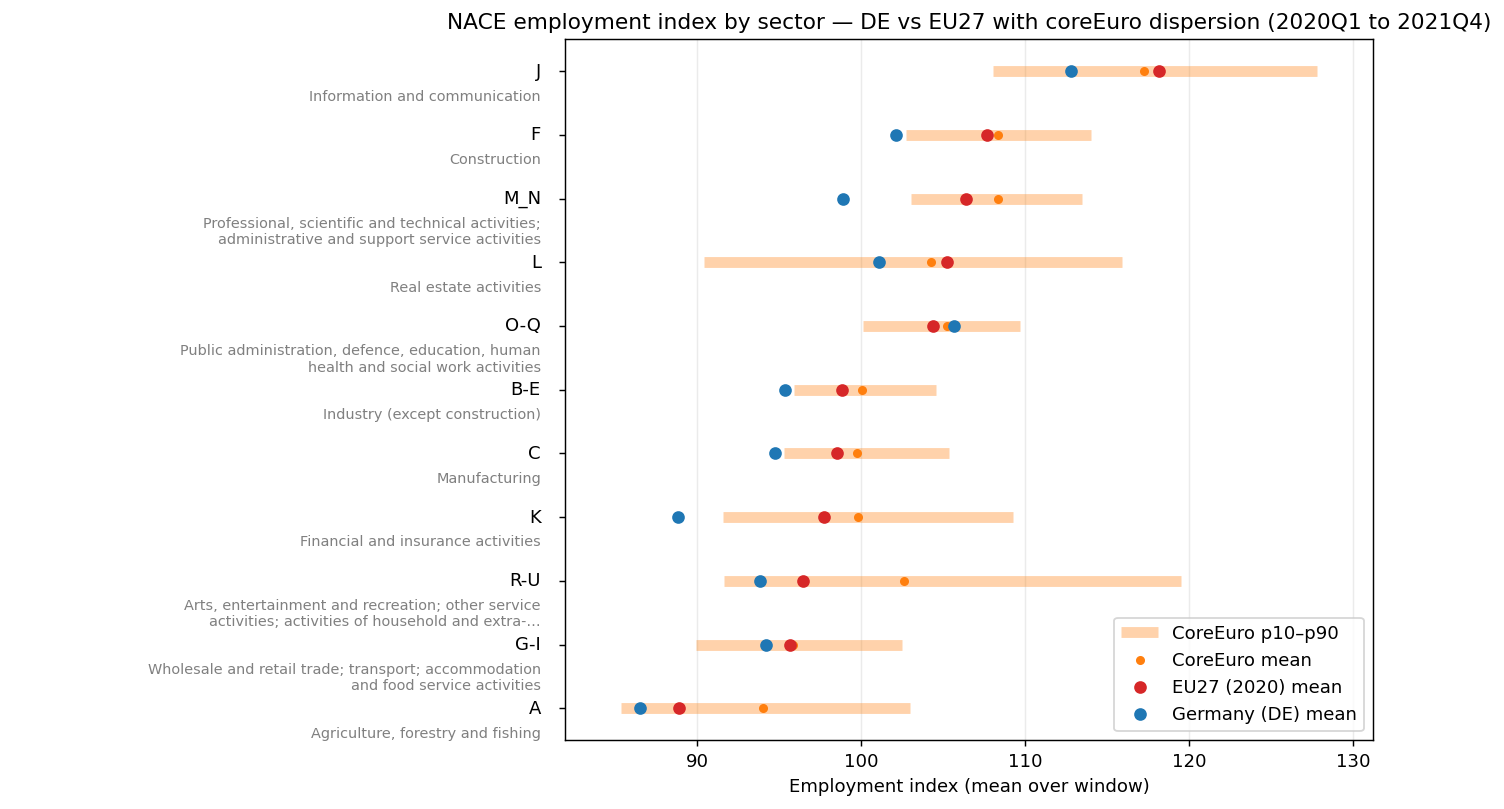

In [11]:
# Cell 13 — Re-plot with cleaner code styling (smaller, not bold)

coreColor = "tab:orange"
euColor = "tab:red"
deColor = "tab:blue"

y = np.arange(len(plotDf2))

fig = plt.figure(figsize=(13.5, 7), dpi=130)
gs = fig.add_gridspec(nrows=1, ncols=2, width_ratios=[0.40, 0.60], wspace=0.02)

axLab = fig.add_subplot(gs[0, 0])
ax = fig.add_subplot(gs[0, 1], sharey=axLab)

# Plot axis
ax.hlines(y=y, xmin=plotDf2["coreP10"], xmax=plotDf2["coreP90"], linewidth=6, alpha=0.35, color=coreColor, label="CoreEuro p10–p90")
ax.plot(plotDf2["coreMean"], y, marker="o", linestyle="None", markersize=4, color=coreColor, label="CoreEuro mean")
ax.plot(plotDf2["eu27Mean"], y, marker="o", linestyle="None", markersize=6, color=euColor, label="EU27 (2020) mean")
ax.plot(plotDf2["deMean"], y, marker="o", linestyle="None", markersize=6, color=deColor, label="Germany (DE) mean")

ax.grid(True, axis="x", alpha=0.25)
ax.set_xlabel("Employment index (mean over window)")
ax.set_title(f"NACE employment index by sector — DE vs EU27 with coreEuro dispersion ({windowStart} to {windowEnd})")

xmin = float(np.nanmin(plotDf2["coreP10"].to_numpy()))
xmax = float(np.nanmax(plotDf2["coreP90"].to_numpy()))
pad = 0.08 * (xmax - xmin) if xmax > xmin else 1.0
ax.set_xlim(xmin - pad, xmax + pad)

ax.legend(loc="lower right", frameon=True)

# Label axis
axLab.set_xlim(0, 1)
axLab.set_xticks([])
axLab.set_yticks(y)
axLab.set_yticklabels([])

for spine in axLab.spines.values():
    spine.set_visible(False)
axLab.tick_params(left=False)

for yi, code, lab in zip(y, plotDf2["naceCode"], plotDf2["sectorLabel2L"]):
    axLab.text(0.98, yi, code, ha="right", va="center", fontsize=10, color="black")  # not bold
    axLab.text(0.98, yi + 0.28, lab, ha="right", va="top", fontsize=8, color="gray")

ax.invert_yaxis()
plt.tight_layout()
plt.show()


In [12]:
# Cell — Save Plot 1 (figure + underlying table)


figuresDir.mkdir(parents=True, exist_ok=True)
tablesDir.mkdir(parents=True, exist_ok=True)

stem = f"nace_covid_coreRange_DE_EU27_{windowStart}_{windowEnd}"

figPath = figuresDir / f"{stem}.png"
tablePath = tablesDir / f"{stem}.csv"

# Save figure (assumes the last plot cell created `fig`)
fig.savefig(figPath, dpi=200, bbox_inches="tight")

# Save table behind the plot
exportCols = [
    "naceCode", "sectorLabel",
    "eu27Mean", "deMean", "coreMean", "coreP10", "coreP90",
    "sectorCol"
]
plotDf2[exportCols].to_csv(tablePath, index=False)

print("Saved figure:", figPath)
print("Saved table :", tablePath)


Saved figure: /Users/princebhanusteta/Documents/Projects/euro-macro-inflation-income/reports/figures/eda_nace/nace_covid_coreRange_DE_EU27_2020Q1_2021Q4.png
Saved table : /Users/princebhanusteta/Documents/Projects/euro-macro-inflation-income/reports/tables/eda_nace/nace_covid_coreRange_DE_EU27_2020Q1_2021Q4.csv


 Plot 1 — How to read the figure (COVID window: 2020Q1–2021Q4)

- **Each row is one NACE aggregate sector.** The large code (e.g., **C**, **G-I**, **R-U**) is the sector identifier; the grey text is the full sector name.
- The **orange band** is the **coreEuro dispersion** (**p10–p90** across DE, FR, IT, ES, NL, PL, SE). Wider bands mean core countries experienced more heterogeneous sector outcomes.
- The **orange dot** is the **coreEuro mean** for that sector.
- The **red dot** is the **EU27_2020 mean** (benchmark).
- The **blue dot** is **Germany (DE)**.
- The x-axis is the **mean employment index over the window**. Farther right = higher index level (relative to the index base used in the dataset).

**How to interpret positions**
- If **DE (blue)** is **left of EU27 (red)**, Germany underperforms the EU benchmark in that sector during COVID (lower mean index level over the window).
- If **DE** sits **outside the orange p10–p90 band**, Germany is an outlier relative to the coreEuro peer group in that sector.

Plot 1 — Economic interpretation (what this suggests)

- **Sector heterogeneity during COVID:** Sectors with **wide orange ranges** indicate that the pandemic shock and policy/structure differences produced meaningfully different sector paths across core Europe (not a “single European experience”).
- **Germany’s relative exposure:** Where **Germany is consistently left of EU27/core mean**, it suggests Germany’s sector employment index remained weaker over the COVID window—consistent with either stricter containment measures, slower reopening dynamics, or sector composition effects.
- **Outlier signals:** Sectors where **Germany falls outside the core band** are the most informative for country-specific narratives (e.g., sector structure, labor market institutions, short-time work uptake, sectoral demand sensitivity).
- **Benchmark vs peers:** Differences between **EU27 (red)** and **core mean (orange dot)** remind us that EU27 aggregates include non-core members; Germany can look “normal” vs core while still diverging from EU27, or vice versa.


In [13]:
# Cell — Build DE vs EU27 table (mean over window), NO core band

windowStart = covidStart
windowEnd = covidEnd

maskWindow = (dfNaceWideFiltered["timeQuarter"] >= windowStart) & (dfNaceWideFiltered["timeQuarter"] <= windowEnd)
dfWin = dfNaceWideFiltered.loc[maskWindow].copy()

sectorLevelCols = sorted([c for c in dfWin.columns if c.startswith("employmentIndex_") and not c.startswith("eu27_") and not c.endswith("_vs_eu27")])
sectorLevelCols = [c for c in sectorLevelCols if c != "employmentIndex_TOTAL"]  # drop TOTAL

geoMeans = dfWin.groupby("geo")[sectorLevelCols].mean(numeric_only=True)
eu27Mean = geoMeans.loc["EU27_2020"]
deMean = geoMeans.loc["DE"]

plotDeEuDf = pd.DataFrame({
    "sectorCol": sectorLevelCols,
    "eu27Mean": eu27Mean.values,
    "deMean": deMean.values,
})
plotDeEuDf["deMinusEu27"] = plotDeEuDf["deMean"] - plotDeEuDf["eu27Mean"]

plotDeEuDf["naceCodeSafe"] = plotDeEuDf["sectorCol"].str.replace("employmentIndex_", "", regex=False)
plotDeEuDf["naceCode"] = plotDeEuDf["naceCodeSafe"].map(safeToOrig).fillna(plotDeEuDf["naceCodeSafe"])
plotDeEuDf["sectorLabel"] = plotDeEuDf["naceCode"].map(labelMap).fillna(plotDeEuDf["naceCode"])
plotDeEuDf["sectorLabel2L"] = plotDeEuDf["sectorLabel"].apply(lambda x: wrapTwoLines(x, width=52))

# Order like COICOP: sorted by EU27 level (descending). If you prefer "largest DE-EU27 gaps", tell me.
plotDeEuDf = plotDeEuDf.sort_values("eu27Mean", ascending=False).reset_index(drop=True)

print("Window:", windowStart, "to", windowEnd)
display(plotDeEuDf[["naceCode", "sectorLabel", "eu27Mean", "deMean", "deMinusEu27"]])


Window: 2020Q1 to 2021Q4


,naceCode,sectorLabel,eu27Mean,deMean,deMinusEu27
0,J,Information and communication,118.175,112.8,-5.375
1,F,Construction,107.675,102.1375,-5.5375
2,M_N,"Professional, scientific and technical activit...",106.3875,98.8625,-7.525
3,L,Real estate activities,105.225,101.0625,-4.1625
4,O-Q,"Public administration, defence, education, hum...",104.3625,105.6625,1.3
5,B-E,Industry (except construction),98.825,95.375,-3.45
6,C,Manufacturing,98.525,94.7625,-3.7625
7,K,Financial and insurance activities,97.75,88.85,-8.9
8,R-U,"Arts, entertainment and recreation; other serv...",96.4375,93.8125,-2.625
9,G-I,Wholesale and retail trade; transport; accommo...,95.675,94.2125,-1.4625


/var/folders/24/3d0f7zg559dcdt3smmt22yr40000gn/T/ipykernel_9477/560961881.py:59: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.90])


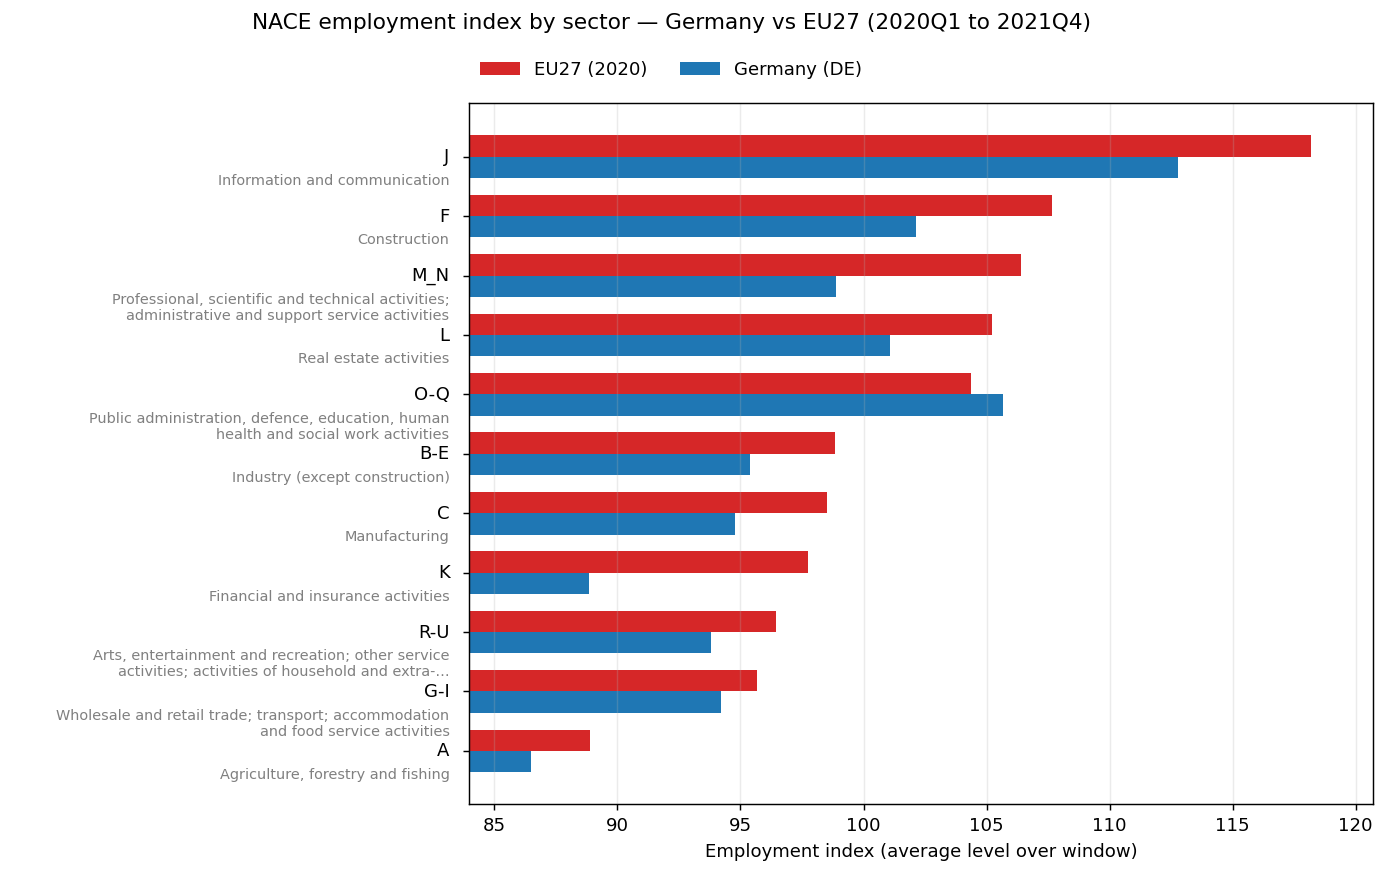

In [14]:
# Cell — Re-plot Plot 2 with proper title/legend spacing (no overlap) + clearer x-label

euColor = "tab:red"
deColor = "tab:blue"

y = np.arange(len(plotDeEuDf))

fig = plt.figure(figsize=(13.5, 7), dpi=130)
gs = fig.add_gridspec(nrows=1, ncols=2, width_ratios=[0.33, 0.67], wspace=0.015)

axLab = fig.add_subplot(gs[0, 0])
ax = fig.add_subplot(gs[0, 1], sharey=axLab)

barH = 0.36
ax.barh(y - barH/2, plotDeEuDf["eu27Mean"], height=barH, color=euColor, label="EU27 (2020)")
ax.barh(y + barH/2, plotDeEuDf["deMean"], height=barH, color=deColor, label="Germany (DE)")

ax.grid(True, axis="x", alpha=0.25)
ax.set_xlabel("Employment index (average level over window)")

# tighter x-lims
vals = np.r_[plotDeEuDf["eu27Mean"].to_numpy(), plotDeEuDf["deMean"].to_numpy()]
xmin = float(np.nanmin(vals))
xmax = float(np.nanmax(vals))
pad = 0.08 * (xmax - xmin) if xmax > xmin else 1.0
ax.set_xlim(xmin - pad, xmax + pad)

# ---- Label axis (left) ----
axLab.set_xlim(0, 1)
axLab.set_xticks([])
axLab.set_yticks(y)
axLab.set_yticklabels([])

for spine in axLab.spines.values():
    spine.set_visible(False)
axLab.tick_params(left=False)

for yi, code, lab in zip(y, plotDeEuDf["naceCode"], plotDeEuDf["sectorLabel2L"]):
    axLab.text(0.98, yi, code, ha="right", va="center", fontsize=10, color="black")
    axLab.text(0.98, yi + 0.28, lab, ha="right", va="top", fontsize=8, color="gray")

ax.invert_yaxis()

# ---- Figure-level title + legend (clean spacing) ----
fig.suptitle(
    f"NACE employment index by sector — Germany vs EU27 ({windowStart} to {windowEnd})",
    y=0.98
)
fig.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 0.945),
    ncol=2,
    frameon=False,
    handlelength=2.2,
    columnspacing=1.8
)

# Reserve top space for title+legend
fig.tight_layout(rect=[0, 0, 1, 0.90])

plt.show()


In [15]:
# Cell — Save Plot 2 (figure + underlying table)

figuresDir.mkdir(parents=True, exist_ok=True)
tablesDir.mkdir(parents=True, exist_ok=True)

stem = f"nace_covid_DE_vs_EU27_{windowStart}_{windowEnd}"

figPath = figuresDir / f"{stem}.png"
tablePath = tablesDir / f"{stem}.csv"

# Save figure (assumes the last plot cell created `fig`)
fig.savefig(figPath, dpi=200, bbox_inches="tight")

# Save table behind the plot
exportCols = ["naceCode", "sectorLabel", "eu27Mean", "deMean", "deMinusEu27"]
plotDeEuDf[exportCols].to_csv(tablePath, index=False)

print("Saved figure:", figPath)
print("Saved table :", tablePath)


Saved figure: /Users/princebhanusteta/Documents/Projects/euro-macro-inflation-income/reports/figures/eda_nace/nace_covid_DE_vs_EU27_2020Q1_2021Q4.png
Saved table : /Users/princebhanusteta/Documents/Projects/euro-macro-inflation-income/reports/tables/eda_nace/nace_covid_DE_vs_EU27_2020Q1_2021Q4.csv


 Plot 2 — How to read the figure (Germany vs EU27, COVID window: 2020Q1–2021Q4)

- Each row is a **NACE sector** (code + full name).
- Bars show the **average employment index level** across **all quarters in the window**:
  - **Red** = **EU27_2020**
  - **Blue** = **Germany (DE)**
- Longer bar = higher average index level over 2020Q1–2021Q4.
- This plot is **not YoY growth**; it is a **level comparison averaged over the window**.

Plot 2 — Economic interpretation (what this tells us)

- Where **Germany < EU27**, Germany’s sector employment index stayed **weaker on average** during the pandemic shock/recovery period, consistent with either deeper contraction, slower reopening, or sector-specific demand sensitivity.
- Where **Germany > EU27**, Germany’s sector held up **relatively better** over the same COVID window, suggesting stronger resilience or faster normalization in that activity.
- Sectors with **large DE–EU27 gaps** are the best candidates for deeper follow-up (policy exposure, sector composition, short-time work intensity, and cross-border demand linkages), and they are also the most informative for downstream ML features (divergence signals).


In [16]:
# Cell — Build "best/worst vs EU27" table for ALL NACE sectors (ex TOTAL) for the current window

windowStart = covidStart
windowEnd = covidEnd

maskWindow = (dfNaceWideFiltered["timeQuarter"] >= windowStart) & (dfNaceWideFiltered["timeQuarter"] <= windowEnd)
dfWin = dfNaceWideFiltered.loc[maskWindow].copy()

sectorLevelCols = sorted([c for c in dfWin.columns if c.startswith("employmentIndex_") and not c.endswith("_vs_eu27") and not c.startswith("eu27_")])
sectorLevelCols = [c for c in sectorLevelCols if c != "employmentIndex_TOTAL"]  # exclude TOTAL

geoMeans = dfWin.groupby("geo")[sectorLevelCols].mean(numeric_only=True)
eu27Mean = geoMeans.loc["EU27_2020"]

geoDeltas = geoMeans.sub(eu27Mean, axis=1).drop(index="EU27_2020")  # Δ vs EU27

# geo label map (robust)
geoNameCol = next((c for c in ["label", "name", "geoName", "country"] if c in dfGeoLabels.columns), None)
geoNameMap = dict(zip(dfGeoLabels["geo"].astype(str), dfGeoLabels[geoNameCol].astype(str))) if geoNameCol else {}

# sector label map (already built earlier as labelMap; safeToOrig for code mapping)
def sectorMetaFromCol(sectorCol: str) -> tuple[str, str]:
    naceCodeSafe = sectorCol.replace("employmentIndex_", "")
    naceCode = safeToOrig.get(naceCodeSafe, naceCodeSafe)
    secLabel = labelMap.get(naceCode, naceCode)
    return naceCode, secLabel

# order sectors by EU27 level (descending) for nicer layout
sectorOrder = sorted(sectorLevelCols, key=lambda c: float(eu27Mean[c]), reverse=True)

rows = []
topK = 3

for sectorCol in sectorOrder:
    s = geoDeltas[sectorCol].dropna().sort_values()
    # bottom (most negative) and top (most positive)
    bottom = s.head(topK)
    top = s.tail(topK).sort_values(ascending=False)

    naceCode, secLabel = sectorMetaFromCol(sectorCol)

    for geo, val in top.items():
        rows.append({
            "sectorCol": sectorCol,
            "naceCode": naceCode,
            "sectorLabel": secLabel,
            "geo": geo,
            "geoLabel": geoNameMap.get(str(geo), str(geo)),
            "deltaVsEu27": float(val),
            "group": "highest"
        })
    for geo, val in bottom.items():
        rows.append({
            "sectorCol": sectorCol,
            "naceCode": naceCode,
            "sectorLabel": secLabel,
            "geo": geo,
            "geoLabel": geoNameMap.get(str(geo), str(geo)),
            "deltaVsEu27": float(val),
            "group": "lowest"
        })

dfNaceBestWorst = pd.DataFrame(rows)

print("Window:", windowStart, "to", windowEnd)
print("Sectors:", len(sectorOrder))
display(dfNaceBestWorst.head(12))


Window: 2020Q1 to 2021Q4
Sectors: 11


,sectorCol,naceCode,sectorLabel,geo,geoLabel,deltaVsEu27,group
0,employmentIndex_J,J,Information and communication,CY,CY,75.3375,highest
1,employmentIndex_J,J,Information and communication,LT,LT,50.9125,highest
2,employmentIndex_J,J,Information and communication,MT,MT,33.4125,highest
3,employmentIndex_J,J,Information and communication,IS,IS,-12.7375,lowest
4,employmentIndex_J,J,Information and communication,IT,IT,-12.4125,lowest
5,employmentIndex_J,J,Information and communication,EE,EE,-11.3625,lowest
6,employmentIndex_F,F,Construction,CY,CY,85.0750,highest
7,employmentIndex_F,F,Construction,MT,MT,43.5000,highest
8,employmentIndex_F,F,Construction,HU,HU,35.2625,highest
9,employmentIndex_F,F,Construction,EE,EE,-19.9125,lowest


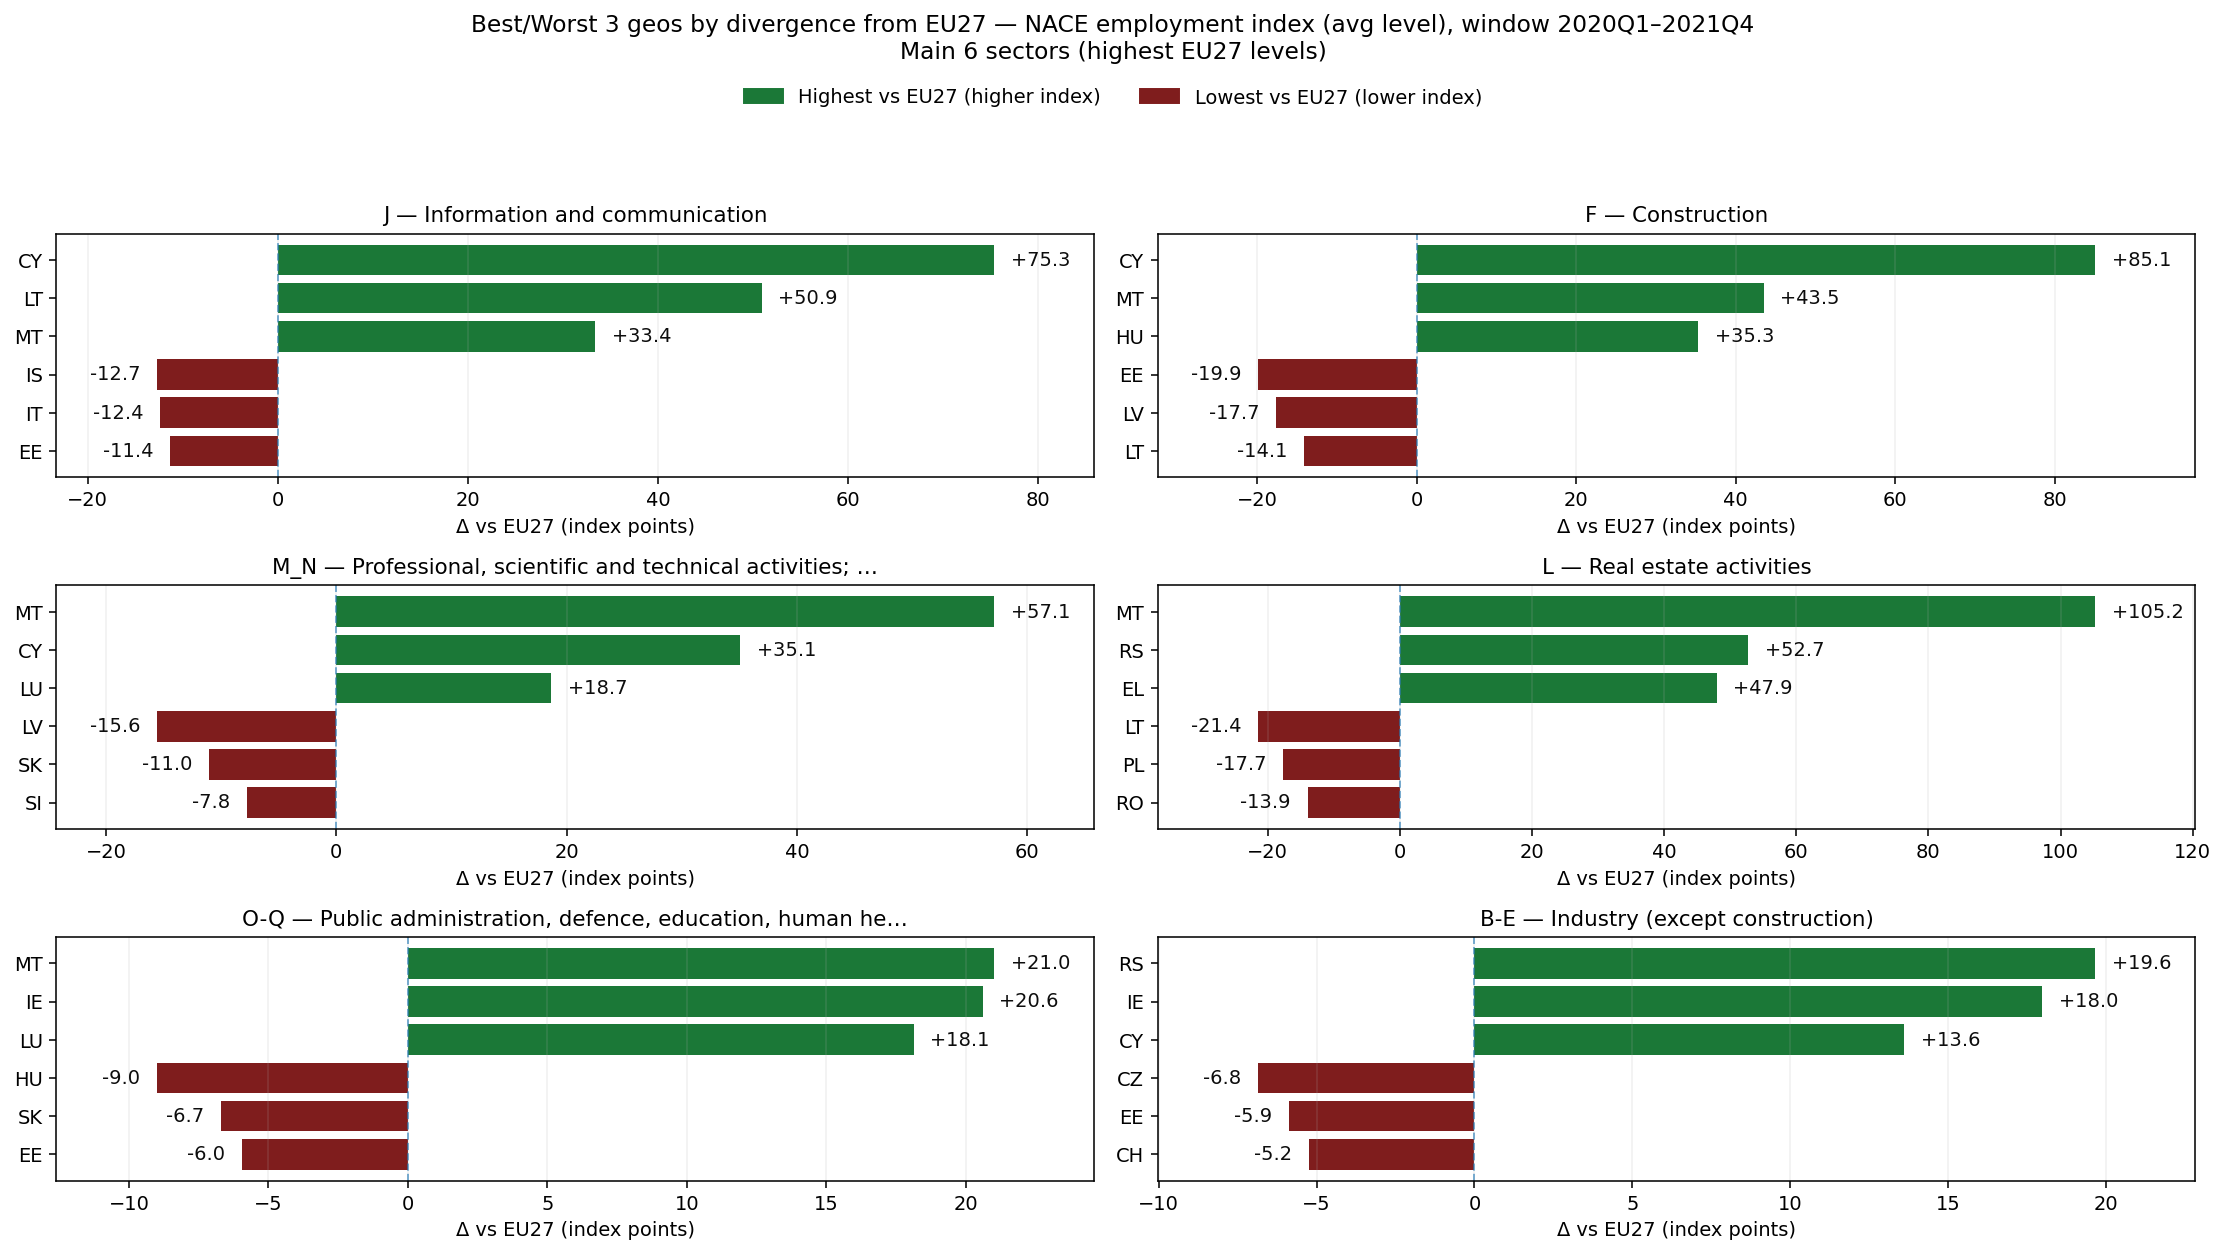

In [17]:
# Cell — Re-plot MAIN 6 sectors (3×2) with clean country labels + dark colors + safe value labels

# Dark colors (closer to COICOP style)
posColor = "#1B7837"  # dark green
negColor = "#7F1D1D"  # dark red

# MAIN 6 sectors: highest EU27 mean level over the window
mainSectors = sectorOrder[:6]

nCols, nRows = 2, 3
fig, axes = plt.subplots(nRows, nCols, figsize=(16, 9), dpi=140)
axes = np.array(axes).reshape(nRows, nCols)

def shortTitle(code: str, label: str, maxLen: int = 52) -> str:
    lab = str(label)
    return f"{code} — {lab}" if len(lab) <= maxLen else f"{code} — {lab[:maxLen-1]}…"

for i, sectorCol in enumerate(mainSectors):
    r, c = divmod(i, nCols)
    ax = axes[r, c]

    sub = dfNaceBestWorst[dfNaceBestWorst["sectorCol"] == sectorCol].copy()
    subPos = sub[sub["group"] == "highest"].sort_values("deltaVsEu27", ascending=False)
    subNeg = sub[sub["group"] == "lowest"].sort_values("deltaVsEu27", ascending=True)
    subPlot = pd.concat([subPos, subNeg], axis=0).reset_index(drop=True)

    y = np.arange(len(subPlot))
    vals = subPlot["deltaVsEu27"].to_numpy()
    colors = [posColor if g == "highest" else negColor for g in subPlot["group"]]

    ax.barh(y, vals, color=colors)
    ax.axvline(0, linestyle="--", linewidth=1, alpha=0.6)

    # Y labels: country name ONLY (no redundant code)
    yLabels = [str(x) for x in subPlot["geoLabel"].tolist()]
    ax.set_yticks(y)
    ax.set_yticklabels(yLabels, fontsize=10)
    ax.invert_yaxis()

    # Add x padding so value labels never hit the frame
    xmin = float(np.nanmin(vals))
    xmax = float(np.nanmax(vals))
    rng = (xmax - xmin) if xmax > xmin else 1.0
    pad = 0.12 * rng
    ax.set_xlim(xmin - pad, xmax + pad)

    # Value labels placed with a small offset; safe with padded xlim
    for yi, v in zip(y, vals):
        offset = 0.02 * rng
        ax.text(
            v + (offset if v >= 0 else -offset),
            yi,
            f"{v:+.1f}",
            va="center",
            ha="left" if v >= 0 else "right",
            fontsize=10,
            alpha=0.95
        )

    naceCode, secLabel = sectorMetaFromCol(sectorCol)
    ax.set_title(shortTitle(naceCode, secLabel), fontsize=11)

    ax.grid(True, axis="x", alpha=0.18)
    ax.set_xlabel("Δ vs EU27 (index points)", fontsize=10)

fig.suptitle(
    f"Best/Worst 3 geos by divergence from EU27 — NACE employment index (avg level), window {windowStart}–{windowEnd}\n"
    f"Main 6 sectors (highest EU27 levels)",
    y=0.99
)

fig.legend(
    handles=[
        Patch(color=posColor, label="Highest vs EU27 (higher index)"),
        Patch(color=negColor, label="Lowest vs EU27 (lower index)")
    ],
    loc="upper center",
    bbox_to_anchor=(0.5, 0.945),
    ncol=2,
    frameon=False
)

fig.tight_layout(rect=[0, 0, 1, 0.91])
plt.show()


In [18]:
# Cell — Save Plot 3 (Best/Worst geos vs EU27) + export table

figuresDir.mkdir(parents=True, exist_ok=True)
tablesDir.mkdir(parents=True, exist_ok=True)

stem = f"nace_bestWorst3_main6_vs_EU27_{windowStart}_{windowEnd}"

figPath = figuresDir / f"{stem}.png"
tablePath = tablesDir / f"{stem}.csv"

# Save figure (assumes the last plot cell created `fig`)
fig.savefig(figPath, dpi=200, bbox_inches="tight")

# Export the underlying long table (contains all sectors, we filtered to main6 only for plotting)
exportCols = ["sectorCol", "naceCode", "sectorLabel", "geo", "geoLabel", "deltaVsEu27", "group"]
dfNaceBestWorst[exportCols].to_csv(tablePath, index=False)

print("Saved figure:", figPath)
print("Saved table :", tablePath)


Saved figure: /Users/princebhanusteta/Documents/Projects/euro-macro-inflation-income/reports/figures/eda_nace/nace_bestWorst3_main6_vs_EU27_2020Q1_2021Q4.png
Saved table : /Users/princebhanusteta/Documents/Projects/euro-macro-inflation-income/reports/tables/eda_nace/nace_bestWorst3_main6_vs_EU27_2020Q1_2021Q4.csv


Plot 3 — How to read the figure (Best/Worst vs EU27, COVID window: 2020Q1–2021Q4)

- Each panel is one **NACE sector** (title shows the sector code + label).
- Bars show the **difference from EU27_2020** in the **average employment index level** over the window:
  - **Green** = the **3 geos with the highest index relative to EU27** (positive divergence)
  - **Dark red** = the **3 geos with the lowest index relative to EU27** (negative divergence)
- The dashed vertical line at **0** means “same as EU27”.
- Values are in **index points** (not %). This is **not YoY growth**; it’s the **average level gap** vs EU27 across the window.

Plot 3 — Economic interpretation (what this tells us)

- This visual highlights **cross-country heterogeneity** inside Europe during COVID: even when the EU benchmark is the same, some countries’ sector employment indices sat far above or below it on average.
- Large positive/negative divergences usually reflect a mix of:
  - **sector composition** (how big/important that sector is locally),
  - **pandemic restrictions + reopening timing**,
  - **labor-market institutions** (e.g., job retention/short-time work),
  - and **exposure to external demand** (tourism, trade, supply chains).
- For ML/feature engineering, these “best/worst divergence” signals are useful to capture **relative resilience vs EU benchmark** by sector and can be turned into:
  - ranking features (top/bottom flags),
  - magnitude features (absolute divergence),
  - and volatility/dispersion features across sectors for each geo.


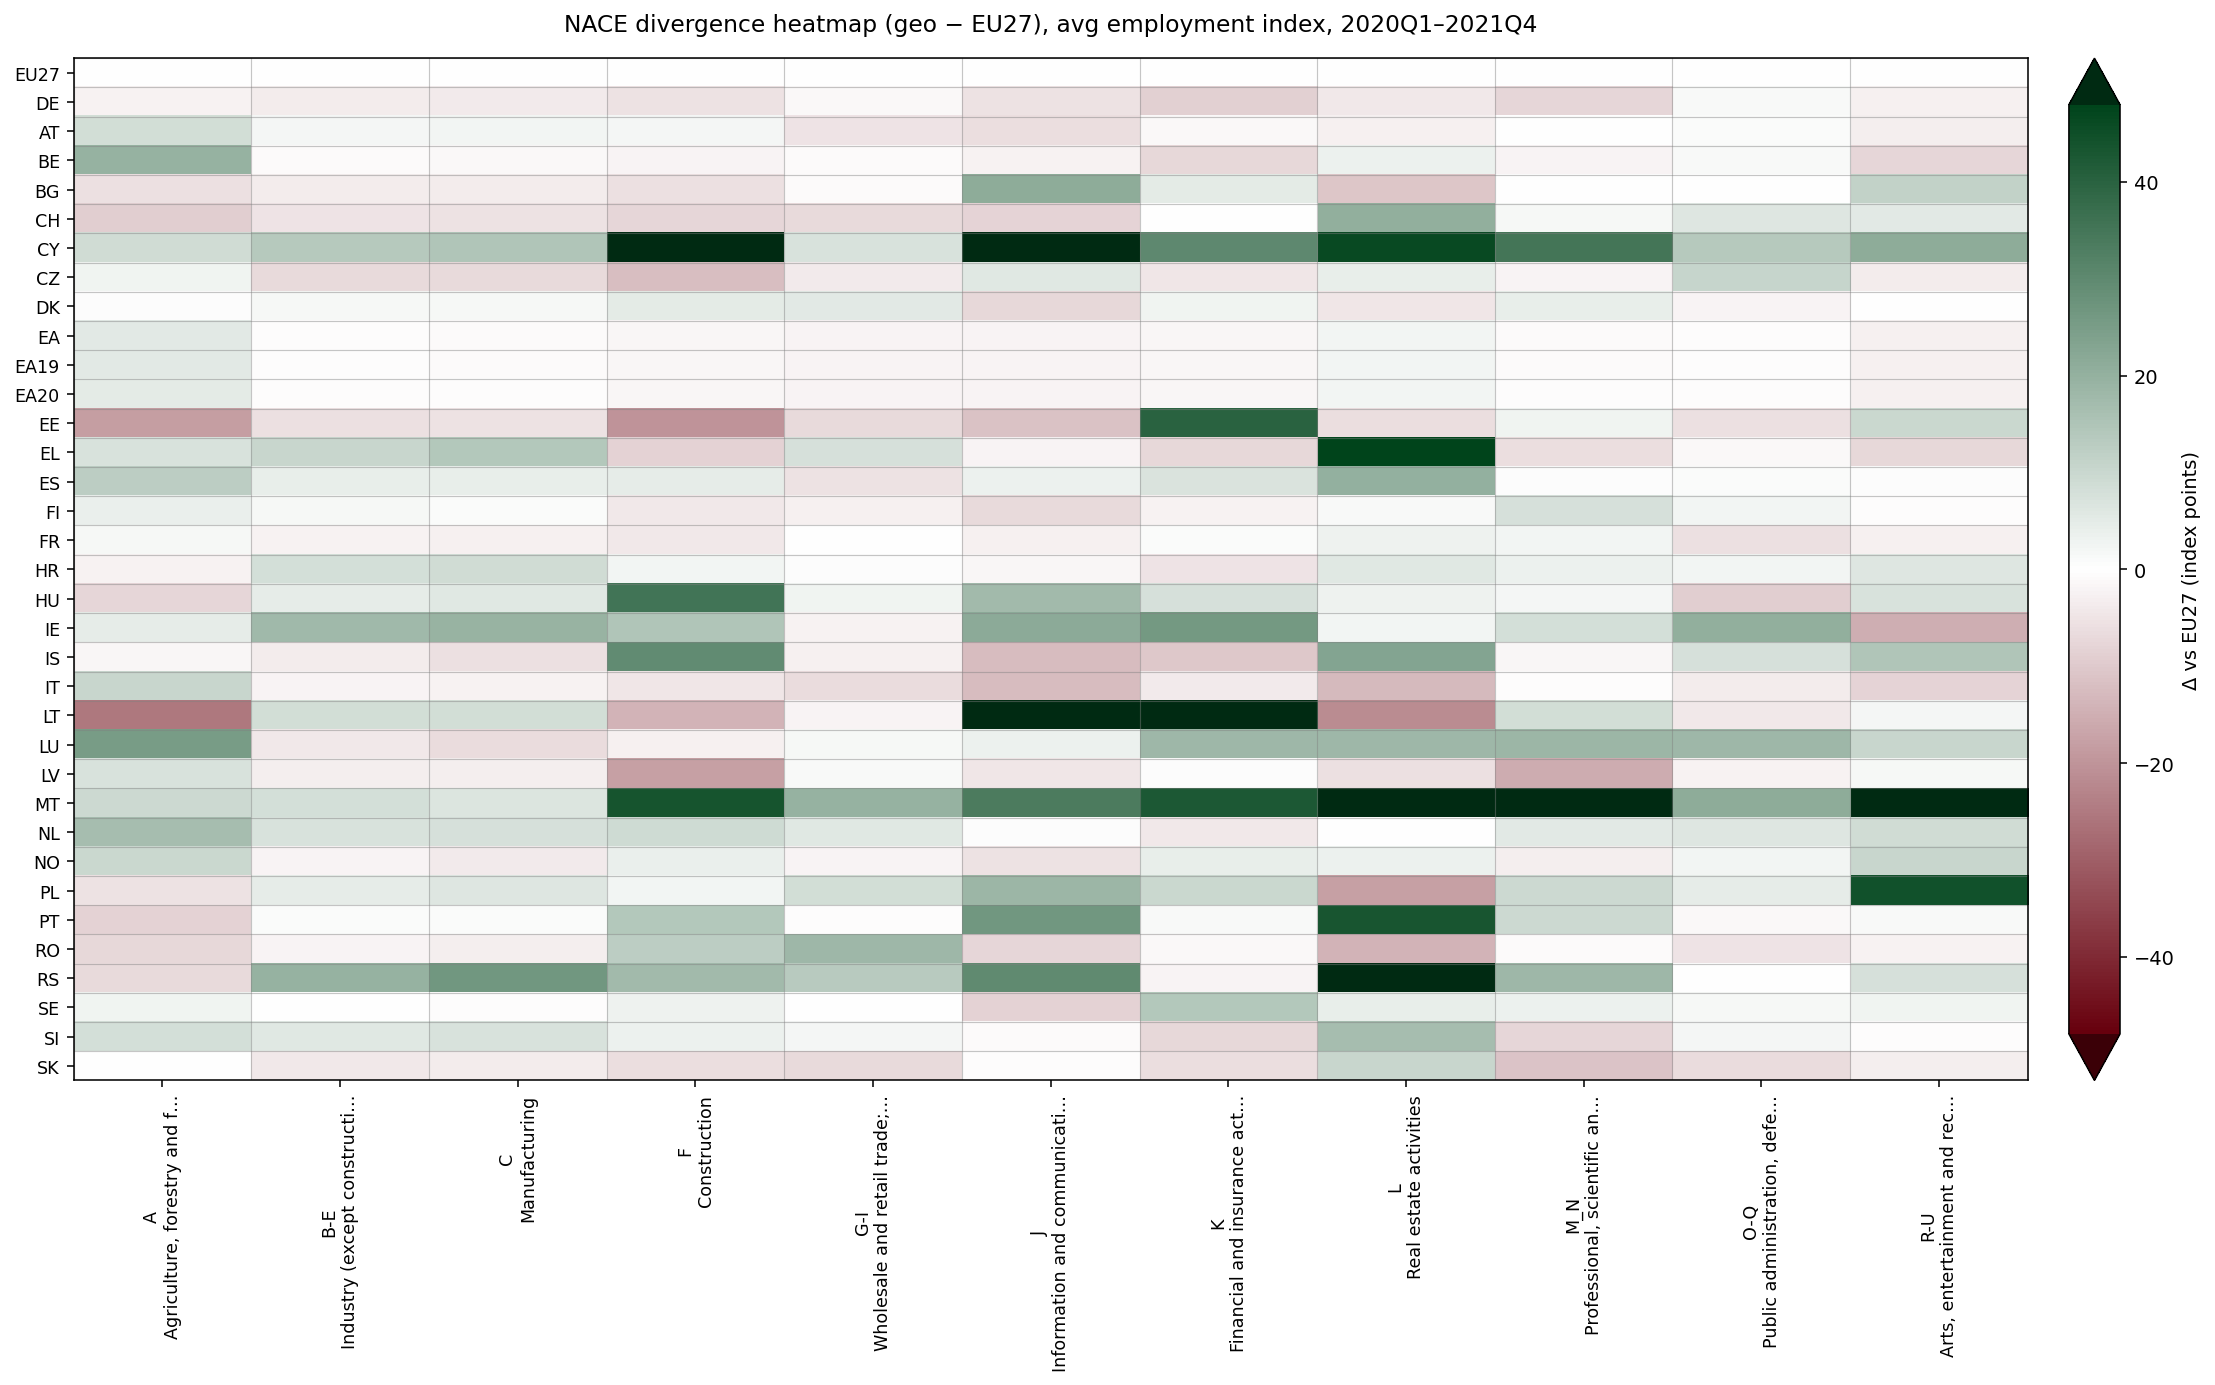

In [19]:
# Cell — NACE divergence heatmap (geo − EU27), avg employment index over window [GREEN=+, RED=−]

windowStart = covidStart
windowEnd = covidEnd

maskWindow = (dfNaceWideFiltered["timeQuarter"] >= windowStart) & (dfNaceWideFiltered["timeQuarter"] <= windowEnd)
dfWin = dfNaceWideFiltered.loc[maskWindow].copy()

# Sector columns (exclude TOTAL + any helper columns)
sectorCols = sorted([
    c for c in dfWin.columns
    if c.startswith("employmentIndex_")
    and not c.endswith("_vs_eu27")
    and c != "employmentIndex_TOTAL"
])

# Force numeric
dfWin[sectorCols] = dfWin[sectorCols].apply(pd.to_numeric, errors="coerce")

# Mean level per geo over the window
geoMeans = dfWin.groupby("geo")[sectorCols].mean()

# EU27 baseline and Δ vs EU27
eu27Key = "EU27_2020"
eu27Mean = geoMeans.loc[eu27Key]
delta = geoMeans.sub(eu27Mean, axis=1)

# Keep EU27 row (all zeros) + order rows (EU27 first, DE second)
rowOrder = [eu27Key]
if "DE" in delta.index:
    rowOrder.append("DE")
rowOrder += sorted([g for g in delta.index if g not in rowOrder])

delta = delta.loc[rowOrder, sectorCols]

# Display labels (geo)
geoTickLabels = [("EU27" if g == eu27Key else g) for g in delta.index]

# Display labels (sectors)
def trunc(s: str, n: int = 28) -> str:
    s = str(s)
    return s if len(s) <= n else s[:n-1] + "…"

sectorTickLabels = []
for col in sectorCols:
    naceSafe = col.replace("employmentIndex_", "")
    naceCode = safeToOrig.get(naceSafe, naceSafe)  # e.g., "G-I"
    secLabel = labelMap.get(naceCode, naceCode)
    sectorTickLabels.append(f"{naceCode}\n{trunc(secLabel, 28)}")

# Numeric matrix
vals = delta.to_numpy(dtype=float)

# --- Robust symmetric scaling (so outliers don't bleach everything else) ---
absFinite = np.abs(vals[np.isfinite(vals)])
if absFinite.size == 0:
    maxAbs = 1.0
else:
    robustQ = 0.98              # 0.98–0.995 works well; set to 1.0 to use true max
    maxAbs = float(np.nanquantile(absFinite, robustQ))
    if (not np.isfinite(maxAbs)) or (maxAbs == 0):
        maxAbs = 1.0

norm = TwoSlopeNorm(vmin=-maxAbs, vcenter=0.0, vmax=maxAbs)

# --- Dark red ↔ white ↔ dark green diverging colormap ---
cmap = LinearSegmentedColormap.from_list(
    "darkRed_white_darkGreen",
    ["#67000d", "#ffffff", "#00441b"],  # dark red, white, dark green
    N=256
)
# Make clipped outliers obvious
cmap.set_under("#3b0007")
cmap.set_over("#002a12")

fig, ax = plt.subplots(figsize=(16, 10), dpi=140)
im = ax.imshow(vals, aspect="auto", cmap=cmap, norm=norm, interpolation="nearest")

ax.set_xticks(np.arange(len(sectorCols)))
ax.set_xticklabels(sectorTickLabels, rotation=90, ha="center", va="top", fontsize=9)

ax.set_yticks(np.arange(len(geoTickLabels)))
ax.set_yticklabels(geoTickLabels, fontsize=9)

# Cell borders / grid
ax.set_xticks(np.arange(-0.5, len(sectorCols), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(geoTickLabels), 1), minor=True)
ax.grid(which="minor", color="gray", linewidth=0.6, alpha=0.45)
ax.tick_params(which="minor", bottom=False, left=False)

ax.set_title(f"NACE divergence heatmap (geo − EU27), avg employment index, {windowStart}–{windowEnd}", pad=14)

cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02, extend="both")
cbar.set_label("Δ vs EU27 (index points)")

plt.tight_layout()
plt.show()


In [20]:
stem = f"nace_divergence_heatmap_allGeos_{windowStart}_{windowEnd}"
figPath = figuresDir / f"{stem}.png"

fig.savefig(figPath, dpi=200, bbox_inches="tight")
print("Saved figure:", figPath)


Saved figure: /Users/princebhanusteta/Documents/Projects/euro-macro-inflation-income/reports/figures/eda_nace/nace_divergence_heatmap_allGeos_2020Q1_2021Q4.png


- **How to read this heatmap**
  - Rows are **geographies** (EU27 benchmark at the top; Germany highlighted just below).
  - Columns are **NACE sectors** (code + short label).
  - Each cell is **Δ vs EU27**, measured as:  
    **(geo’s average employment index over the window) − (EU27’s average employment index over the same window)**.
  - **Red** means the country’s employment index level in that sector was **above** EU27 on average; **blue** means **below**.
  - EU27’s row should be ~**0 everywhere** by construction (it’s the reference).

- **Economic interpretation (2020Q1–2021Q4 window)**
  - This is a **relative sectoral positioning** chart: it shows *which countries were structurally “hotter” or “colder” than the EU27 baseline* in each sector during the Covid-era window.
  - Broad red patterns for a country suggest **systematically higher employment index levels** than EU27 across multiple sectors (potentially stronger labor market resilience / composition effects).
  - Mixed red/blue patterns suggest **sector-specific divergence**, i.e., resilience (or weakness) concentrated in particular industries rather than economy-wide.
  - Use this mainly to identify **outliers and clusters** (countries that deviate strongly in specific sectors), which is useful both for narrative EDA and for later **feature engineering** (e.g., “sector divergence profile” features).


In [21]:
from pathlib import Path
import pandas as pd

def findProjectRoot(startPath: Path | None = None, markerDir: str = "data_processed"):
    startPath = Path.cwd() if startPath is None else startPath
    for p in [startPath, *startPath.parents]:
        if (p / markerDir).exists():
            return p
    raise FileNotFoundError(f"Could not find project root containing '{markerDir}'")

projectRoot = findProjectRoot()
reportsDir  = projectRoot / "reports"
figuresDir  = reportsDir / "figures" / "eda_nace"
tablesDir   = reportsDir / "tables" / "eda_nace"
figuresDir.mkdir(parents=True, exist_ok=True)
tablesDir.mkdir(parents=True, exist_ok=True)

# SURGE / post-covid window (your notebook constants already match this)
windowStart = pd.Period("2022Q1", freq="Q-DEC")
windowEnd   = pd.Period("2024Q4", freq="Q-DEC")

print("projectRoot:", projectRoot)
print("Saving figures to:", figuresDir)
print("Saving tables  to:", tablesDir)
print("Window:", windowStart, "→", windowEnd)


projectRoot: /Users/princebhanusteta/Documents/Projects/euro-macro-inflation-income
Saving figures to: /Users/princebhanusteta/Documents/Projects/euro-macro-inflation-income/reports/figures/eda_nace
Saving tables  to: /Users/princebhanusteta/Documents/Projects/euro-macro-inflation-income/reports/tables/eda_nace
Window: 2022Q1 → 2024Q4


/var/folders/24/3d0f7zg559dcdt3smmt22yr40000gn/T/ipykernel_9477/3565910299.py:94: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


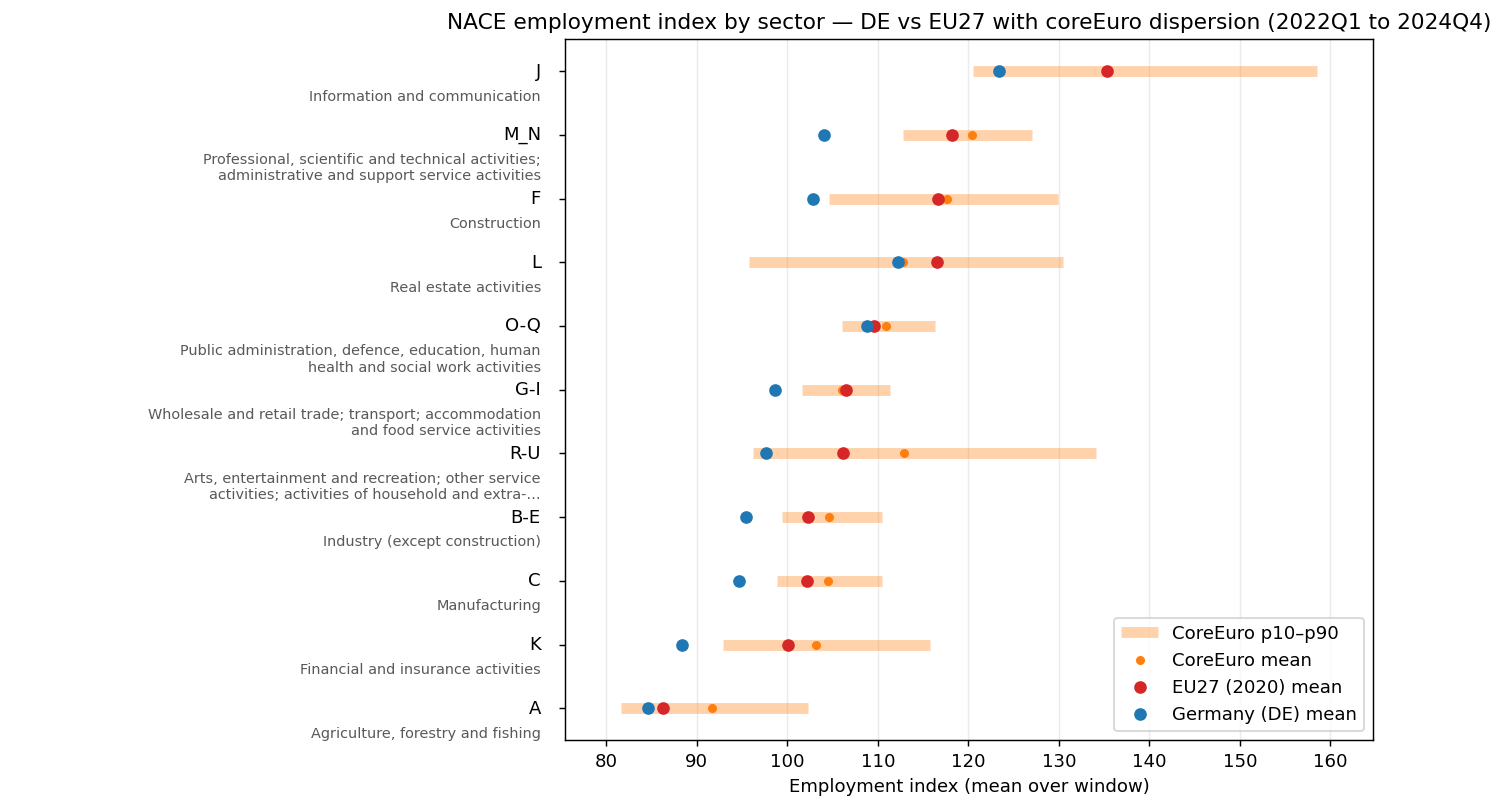

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import textwrap

# --- helpers (same behavior as notebook) ---
def wrapTwoLines(s: str, width: int = 52) -> str:
    parts = textwrap.wrap(str(s), width=width)
    if len(parts) <= 2:
        return "\n".join(parts)
    return "\n".join(parts[:2]).rstrip() + "…"

# --- window slice ---
maskWindow = (dfNaceWideFiltered["timeQuarter"] >= windowStart) & (dfNaceWideFiltered["timeQuarter"] <= windowEnd)
dfWin = dfNaceWideFiltered.loc[maskWindow].copy()

# IMPORTANT: keep ONLY level columns, exclude divergences & EU27-prefixed columns
sectorLevelCols = sorted([
    c for c in dfWin.columns
    if c.startswith("employmentIndex_") and (not c.endswith("_vs_eu27"))
])

# drop TOTAL for the clean version (matches notebook)
sectorLevelCols = [c for c in sectorLevelCols if c != "employmentIndex_TOTAL"]

geoMeans = dfWin.groupby("geo")[sectorLevelCols].mean(numeric_only=True)
eu27Mean = geoMeans.loc["EU27_2020"]
deMean   = geoMeans.loc["DE"]

# core peers (use your existing list from the notebook)
corePeers = [g for g in coreEuroGeos if g in geoMeans.index and g != "EU27_2020"]
coreMat   = geoMeans.loc[corePeers]

plotDf = pd.DataFrame({
    "sectorCol": sectorLevelCols,
    "eu27Mean": eu27Mean.values,
    "deMean": deMean.values,
    "coreMean": coreMat.mean(axis=0).values,
    "coreP10": coreMat.quantile(0.10, axis=0).values,
    "coreP90": coreMat.quantile(0.90, axis=0).values,
})

plotDf["naceCodeSafe"] = plotDf["sectorCol"].str.replace("employmentIndex_", "", regex=False)
origSectors = sorted(dfNace["nace_r2"].unique().tolist())
safeToOrig  = {s.replace("-", "_"): s for s in origSectors}
plotDf["naceCode"] = plotDf["naceCodeSafe"].map(safeToOrig).fillna(plotDf["naceCodeSafe"])

labelCol = "label" if "label" in dfNaceLabels.columns else dfNaceLabels.columns[-1]
labelMap = dict(zip(dfNaceLabels["nace_r2"].astype(str), dfNaceLabels[labelCol].astype(str)))
plotDf["sectorLabel"]   = plotDf["naceCode"].map(labelMap).fillna(plotDf["naceCode"])
plotDf["sectorLabel2L"] = plotDf["sectorLabel"].apply(lambda x: wrapTwoLines(x, 52))

# sort by EU27 level desc (same as notebook)
plotDf = plotDf.sort_values("eu27Mean", ascending=False).reset_index(drop=True)

coreColor = "tab:orange"
euColor   = "tab:red"
deColor   = "tab:blue"

y = np.arange(len(plotDf))
fig = plt.figure(figsize=(13.5, 7), dpi=130)
gs = fig.add_gridspec(nrows=1, ncols=2, width_ratios=[0.40, 0.60], wspace=0.02)
axLab = fig.add_subplot(gs[0, 0])
ax    = fig.add_subplot(gs[0, 1], sharey=axLab)

ax.hlines(y=y, xmin=plotDf["coreP10"], xmax=plotDf["coreP90"], linewidth=6, color=coreColor, alpha=0.35, label="CoreEuro p10–p90")
ax.plot(plotDf["coreMean"], y, marker="o", linestyle="None", markersize=4, color=coreColor, label="CoreEuro mean")
ax.plot(plotDf["eu27Mean"], y, marker="o", linestyle="None", markersize=6, color=euColor, label="EU27 (2020) mean")
ax.plot(plotDf["deMean"],   y, marker="o", linestyle="None", markersize=6, color=deColor, label="Germany (DE) mean")

ax.grid(True, axis="x", alpha=0.25)
ax.set_xlabel("Employment index (mean over window)")
ax.set_title(f"NACE employment index by sector — DE vs EU27 with coreEuro dispersion ({windowStart} to {windowEnd})")

xmin = float(np.nanmin(plotDf["coreP10"].to_numpy()))
xmax = float(np.nanmax(plotDf["coreP90"].to_numpy()))
pad  = 0.08 * (xmax - xmin) if xmax > xmin else 1.0
ax.set_xlim(xmin - pad, xmax + pad)
ax.legend(loc="lower right", frameon=True)

# left label axis
axLab.set_xlim(0, 1)
axLab.set_xticks([])
axLab.set_yticks(y)
axLab.set_yticklabels([])
for spine in axLab.spines.values():
    spine.set_visible(False)
axLab.tick_params(left=False)

for yi, code, lab in zip(y, plotDf["naceCode"], plotDf["sectorLabel2L"]):
    axLab.text(0.98, yi, code, ha="right", va="center", fontsize=10, color="black")
    axLab.text(0.98, yi + 0.28, lab, ha="right", va="top", fontsize=8, color="0.35")

ax.invert_yaxis()
plt.tight_layout()
plt.show()


In [23]:
stem = f"nace_surge_coreRange_DE_EU27_{windowStart}_{windowEnd}"
figPath   = figuresDir / f"{stem}.png"
tablePath = tablesDir  / f"{stem}.csv"

fig.savefig(figPath, dpi=200, bbox_inches="tight")
plotDf[["naceCode","sectorLabel","eu27Mean","deMean","coreMean","coreP10","coreP90","sectorCol"]].to_csv(tablePath, index=False)

print("Saved figure:", figPath)
print("Saved table :", tablePath)


Saved figure: /Users/princebhanusteta/Documents/Projects/euro-macro-inflation-income/reports/figures/eda_nace/nace_surge_coreRange_DE_EU27_2022Q1_2024Q4.png
Saved table : /Users/princebhanusteta/Documents/Projects/euro-macro-inflation-income/reports/tables/eda_nace/nace_surge_coreRange_DE_EU27_2022Q1_2024Q4.csv


/var/folders/24/3d0f7zg559dcdt3smmt22yr40000gn/T/ipykernel_9477/1001697367.py:73: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.90])


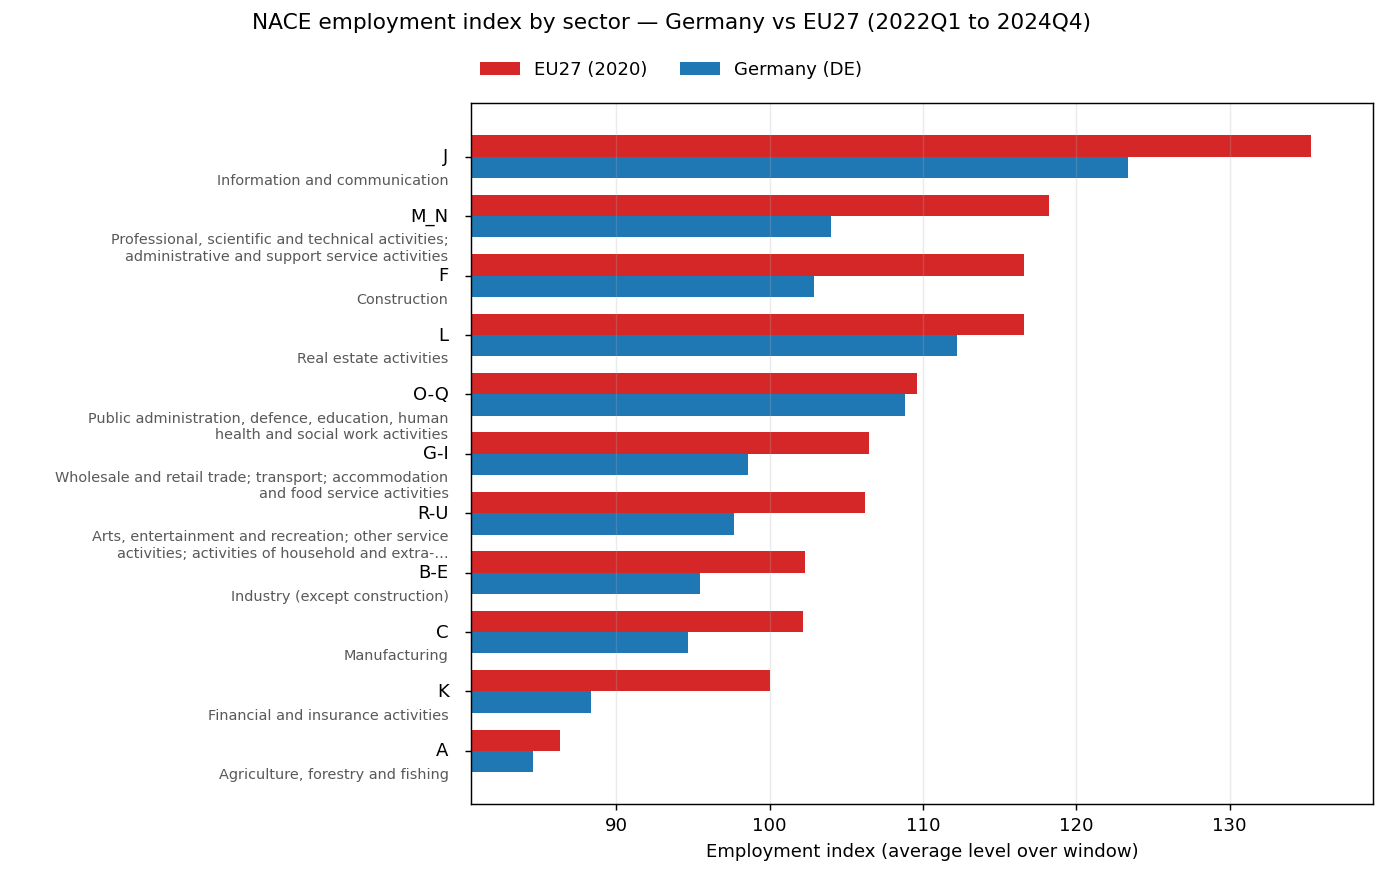

In [24]:
def wrapTwoLines(s: str, width: int = 52) -> str:
    parts = textwrap.wrap(str(s), width=width)
    if len(parts) <= 2:
        return "\n".join(parts)
    return "\n".join(parts[:2]).rstrip() + "…"

maskWindow = (dfNaceWideFiltered["timeQuarter"] >= windowStart) & (dfNaceWideFiltered["timeQuarter"] <= windowEnd)
dfWin = dfNaceWideFiltered.loc[maskWindow].copy()

sectorLevelCols = sorted([
    c for c in dfWin.columns
    if c.startswith("employmentIndex_") and (not c.endswith("_vs_eu27"))
])
sectorLevelCols = [c for c in sectorLevelCols if c != "employmentIndex_TOTAL"]

geoMeans = dfWin.groupby("geo")[sectorLevelCols].mean(numeric_only=True)
eu27Mean = geoMeans.loc["EU27_2020"]
deMean   = geoMeans.loc["DE"]

plotDeEuDf = pd.DataFrame({"sectorCol": sectorLevelCols, "eu27Mean": eu27Mean.values, "deMean": deMean.values})
plotDeEuDf["deMinusEu27"] = plotDeEuDf["deMean"] - plotDeEuDf["eu27Mean"]

origSectors = sorted(dfNace["nace_r2"].unique().tolist())
safeToOrig  = {s.replace("-", "_"): s for s in origSectors}
labelCol = "label" if "label" in dfNaceLabels.columns else dfNaceLabels.columns[-1]
labelMap = dict(zip(dfNaceLabels["nace_r2"].astype(str), dfNaceLabels[labelCol].astype(str)))

plotDeEuDf["naceCodeSafe"] = plotDeEuDf["sectorCol"].str.replace("employmentIndex_", "", regex=False)
plotDeEuDf["naceCode"]     = plotDeEuDf["naceCodeSafe"].map(safeToOrig).fillna(plotDeEuDf["naceCodeSafe"])
plotDeEuDf["sectorLabel"]  = plotDeEuDf["naceCode"].map(labelMap).fillna(plotDeEuDf["naceCode"])
plotDeEuDf["sectorLabel2L"] = plotDeEuDf["sectorLabel"].apply(lambda x: wrapTwoLines(x, 52))

plotDeEuDf = plotDeEuDf.sort_values("eu27Mean", ascending=False).reset_index(drop=True)

euColor = "tab:red"
deColor = "tab:blue"
y = np.arange(len(plotDeEuDf))

fig = plt.figure(figsize=(13.5, 7), dpi=130)
gs = fig.add_gridspec(nrows=1, ncols=2, width_ratios=[0.33, 0.67], wspace=0.02)
axLab = fig.add_subplot(gs[0, 0])
ax    = fig.add_subplot(gs[0, 1], sharey=axLab)

barH = 0.36
ax.barh(y - barH/2, plotDeEuDf["eu27Mean"], height=barH, color=euColor, label="EU27 (2020)")
ax.barh(y + barH/2, plotDeEuDf["deMean"],   height=barH, color=deColor, label="Germany (DE)")

ax.grid(True, axis="x", alpha=0.25)
ax.set_xlabel("Employment index (average level over window)")

vals = np.r_[plotDeEuDf["eu27Mean"].to_numpy(), plotDeEuDf["deMean"].to_numpy()]
xmin, xmax = float(np.nanmin(vals)), float(np.nanmax(vals))
pad = 0.08 * (xmax - xmin) if xmax > xmin else 1.0
ax.set_xlim(xmin - pad, xmax + pad)

# left label axis
axLab.set_xlim(0, 1)
axLab.set_xticks([])
axLab.set_yticks(y)
axLab.set_yticklabels([])
for spine in axLab.spines.values():
    spine.set_visible(False)
axLab.tick_params(left=False)

for yi, code, lab in zip(y, plotDeEuDf["naceCode"], plotDeEuDf["sectorLabel2L"]):
    axLab.text(0.98, yi, code, ha="right", va="center", fontsize=10, color="black")
    axLab.text(0.98, yi + 0.28, lab, ha="right", va="top", fontsize=8, color="0.35")

ax.invert_yaxis()

fig.suptitle(f"NACE employment index by sector — Germany vs EU27 ({windowStart} to {windowEnd})", y=0.98)
fig.legend(loc="upper center", bbox_to_anchor=(0.5, 0.945), ncol=2, frameon=False, handlelength=2.2, columnspacing=1.8)
fig.tight_layout(rect=[0, 0, 1, 0.90])
plt.show()


In [25]:
stem = f"nace_surge_DE_vs_EU27_{windowStart}_{windowEnd}"
figPath   = figuresDir / f"{stem}.png"
tablePath = tablesDir  / f"{stem}.csv"

fig.savefig(figPath, dpi=200, bbox_inches="tight")
plotDeEuDf[["naceCode","sectorLabel","eu27Mean","deMean","deMinusEu27"]].to_csv(tablePath, index=False)

print("Saved figure:", figPath)
print("Saved table :", tablePath)


Saved figure: /Users/princebhanusteta/Documents/Projects/euro-macro-inflation-income/reports/figures/eda_nace/nace_surge_DE_vs_EU27_2022Q1_2024Q4.png
Saved table : /Users/princebhanusteta/Documents/Projects/euro-macro-inflation-income/reports/tables/eda_nace/nace_surge_DE_vs_EU27_2022Q1_2024Q4.csv


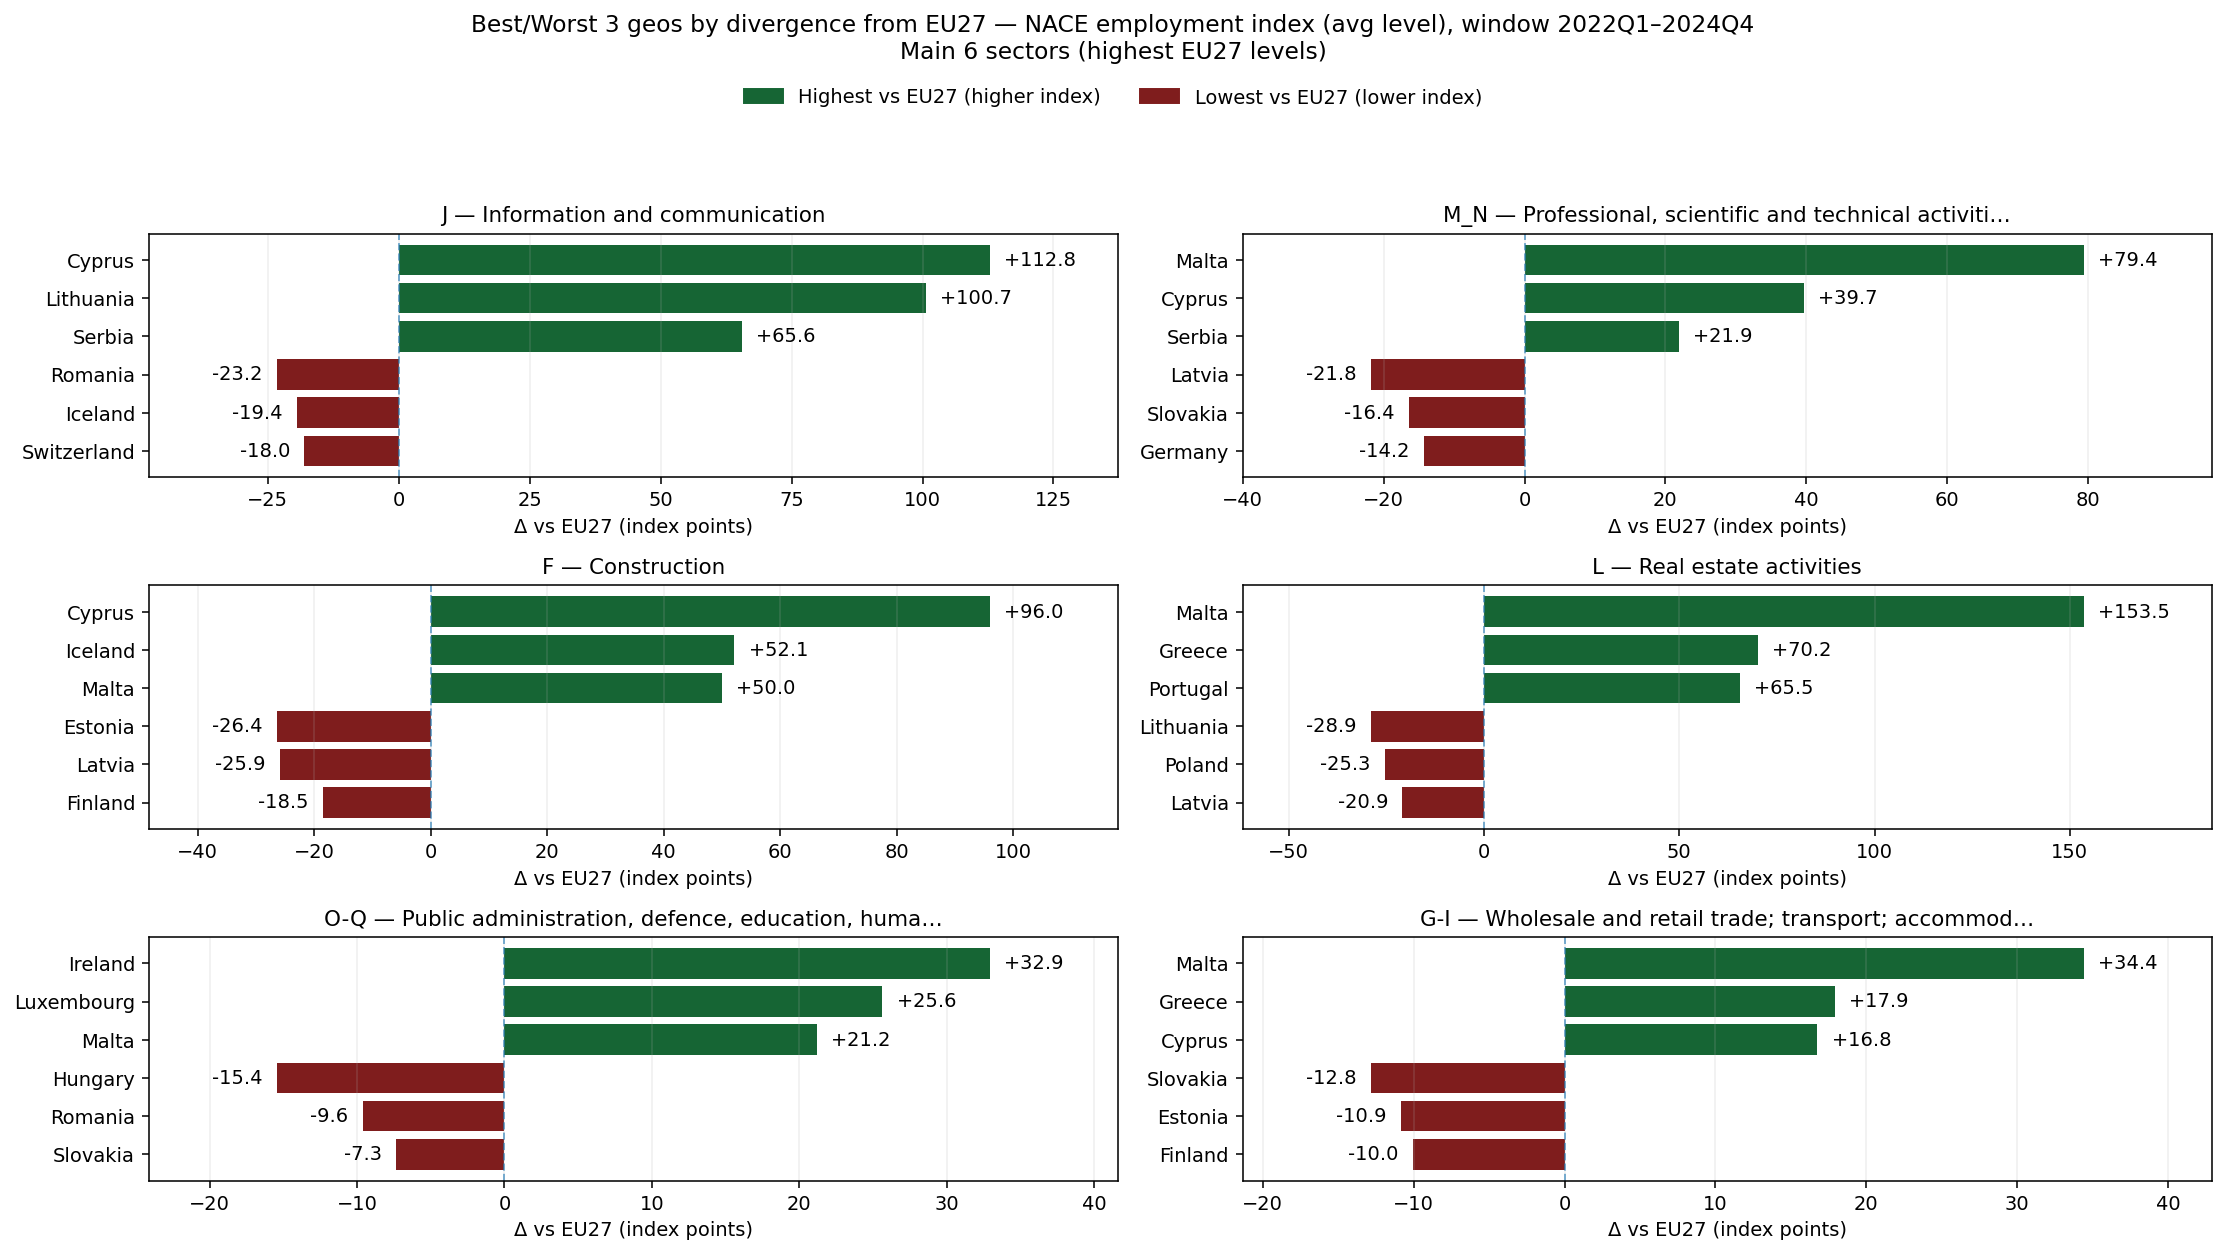

In [26]:
maskWindow = (dfNaceWideFiltered["timeQuarter"] >= windowStart) & (dfNaceWideFiltered["timeQuarter"] <= windowEnd)
dfWin = dfNaceWideFiltered.loc[maskWindow].copy()

sectorLevelCols = sorted([
    c for c in dfWin.columns
    if c.startswith("employmentIndex_") and (not c.endswith("_vs_eu27"))
])
sectorLevelCols = [c for c in sectorLevelCols if c != "employmentIndex_TOTAL"]

geoMeans = dfWin.groupby("geo")[sectorLevelCols].mean(numeric_only=True)
eu27Mean = geoMeans.loc["EU27_2020"]
geoDeltas = geoMeans.sub(eu27Mean, axis=1).drop(index="EU27_2020")

geoNameCol = next((c for c in ["label","name","geoName","country"] if c in dfGeoLabels.columns), dfGeoLabels.columns[-1])
geoNameMap = dict(zip(dfGeoLabels["geo"].astype(str), dfGeoLabels[geoNameCol].astype(str)))

origSectors = sorted(dfNace["nace_r2"].unique().tolist())
safeToOrig  = {s.replace("-", "_"): s for s in origSectors}
labelCol = "label" if "label" in dfNaceLabels.columns else dfNaceLabels.columns[-1]
labelMap = dict(zip(dfNaceLabels["nace_r2"].astype(str), dfNaceLabels[labelCol].astype(str)))

def sectorMetaFromCol(sectorCol: str):
    naceCodeSafe = sectorCol.replace("employmentIndex_", "")
    naceCode = safeToOrig.get(naceCodeSafe, naceCodeSafe)
    secLabel = labelMap.get(naceCode, naceCode)
    return naceCode, secLabel

sectorOrder = sorted(sectorLevelCols, key=lambda c: float(eu27Mean[c]), reverse=True)

rows = []
topK = 3
for sectorCol in sectorOrder:
    s = geoDeltas[sectorCol].dropna().sort_values()
    bottom = s.head(topK)
    top    = s.tail(topK).sort_values(ascending=False)
    naceCode, secLabel = sectorMetaFromCol(sectorCol)

    for geo, val in top.items():
        rows.append({"sectorCol": sectorCol, "naceCode": naceCode, "sectorLabel": secLabel,
                     "geo": geo, "geoLabel": geoNameMap.get(str(geo), str(geo)),
                     "deltaVsEu27": float(val), "group": "highest"})
    for geo, val in bottom.items():
        rows.append({"sectorCol": sectorCol, "naceCode": naceCode, "sectorLabel": secLabel,
                     "geo": geo, "geoLabel": geoNameMap.get(str(geo), str(geo)),
                     "deltaVsEu27": float(val), "group": "lowest"})

dfNaceBestWorst = pd.DataFrame(rows)

posColor = "#166534"   # dark green
negColor = "#7f1d1d"   # dark red

mainSectors = sectorOrder[:6]
nCols, nRows = 2, 3
fig, axes = plt.subplots(nRows, nCols, figsize=(16, 9), dpi=140)
axes = np.array(axes).reshape(nRows, nCols)

def shortTitle(code: str, label: str, maxLen: int = 48) -> str:
    lab = str(label)
    return f"{code} — {lab}" if len(lab) <= maxLen else f"{code} — {lab[:maxLen-1]}…"

for i, sectorCol in enumerate(mainSectors):
    r, c = divmod(i, nCols)
    ax = axes[r, c]

    sub = dfNaceBestWorst[dfNaceBestWorst["sectorCol"] == sectorCol].copy()
    subPos = sub[sub["group"] == "highest"].sort_values("deltaVsEu27", ascending=False)
    subNeg = sub[sub["group"] == "lowest"].sort_values("deltaVsEu27", ascending=True)
    subPlot = pd.concat([subPos, subNeg], axis=0).reset_index(drop=True)

    y = np.arange(len(subPlot))
    colors = [posColor if g == "highest" else negColor for g in subPlot["group"]]

    ax.barh(y, subPlot["deltaVsEu27"], color=colors)
    ax.axvline(0, linestyle="--", linewidth=1, alpha=0.6)

    # ONLY country name (no redundant code)
    ax.set_yticks(y)
    ax.set_yticklabels(subPlot["geoLabel"].tolist(), fontsize=10)
    ax.invert_yaxis()

    # value labels with padding so they don't crash into the box
    vmin = float(np.nanmin(subPlot["deltaVsEu27"]))
    vmax = float(np.nanmax(subPlot["deltaVsEu27"]))
    span = max(vmax - vmin, 1.0)
    ax.set_xlim(vmin - 0.18*span, vmax + 0.18*span)

    for yi, val in zip(y, subPlot["deltaVsEu27"]):
        ax.text(val + (0.02*span if val >= 0 else -0.02*span),
                yi, f"{val:+.1f}",
                va="center", ha="left" if val >= 0 else "right", fontsize=10)

    naceCode, secLabel = sectorMetaFromCol(sectorCol)
    ax.set_title(shortTitle(naceCode, secLabel), fontsize=11)
    ax.grid(True, axis="x", alpha=0.20)
    ax.set_xlabel("Δ vs EU27 (index points)", fontsize=10)

fig.suptitle(
    f"Best/Worst 3 geos by divergence from EU27 — NACE employment index (avg level), window {windowStart}–{windowEnd}\n"
    f"Main 6 sectors (highest EU27 levels)",
    y=0.99
)
fig.legend(
    handles=[Patch(color=posColor, label="Highest vs EU27 (higher index)"),
             Patch(color=negColor, label="Lowest vs EU27 (lower index)")],
    loc="upper center", bbox_to_anchor=(0.5, 0.945), ncol=2, frameon=False
)
fig.tight_layout(rect=[0, 0, 1, 0.91])
plt.show()


In [27]:
stem = f"nace_bestWorst3_main6_vs_EU27_{windowStart}_{windowEnd}"
figPath   = figuresDir / f"{stem}.png"
tablePath = tablesDir  / f"{stem}.csv"

fig.savefig(figPath, dpi=200, bbox_inches="tight")
dfNaceBestWorst.to_csv(tablePath, index=False)

print("Saved figure:", figPath)
print("Saved table :", tablePath)


Saved figure: /Users/princebhanusteta/Documents/Projects/euro-macro-inflation-income/reports/figures/eda_nace/nace_bestWorst3_main6_vs_EU27_2022Q1_2024Q4.png
Saved table : /Users/princebhanusteta/Documents/Projects/euro-macro-inflation-income/reports/tables/eda_nace/nace_bestWorst3_main6_vs_EU27_2022Q1_2024Q4.csv


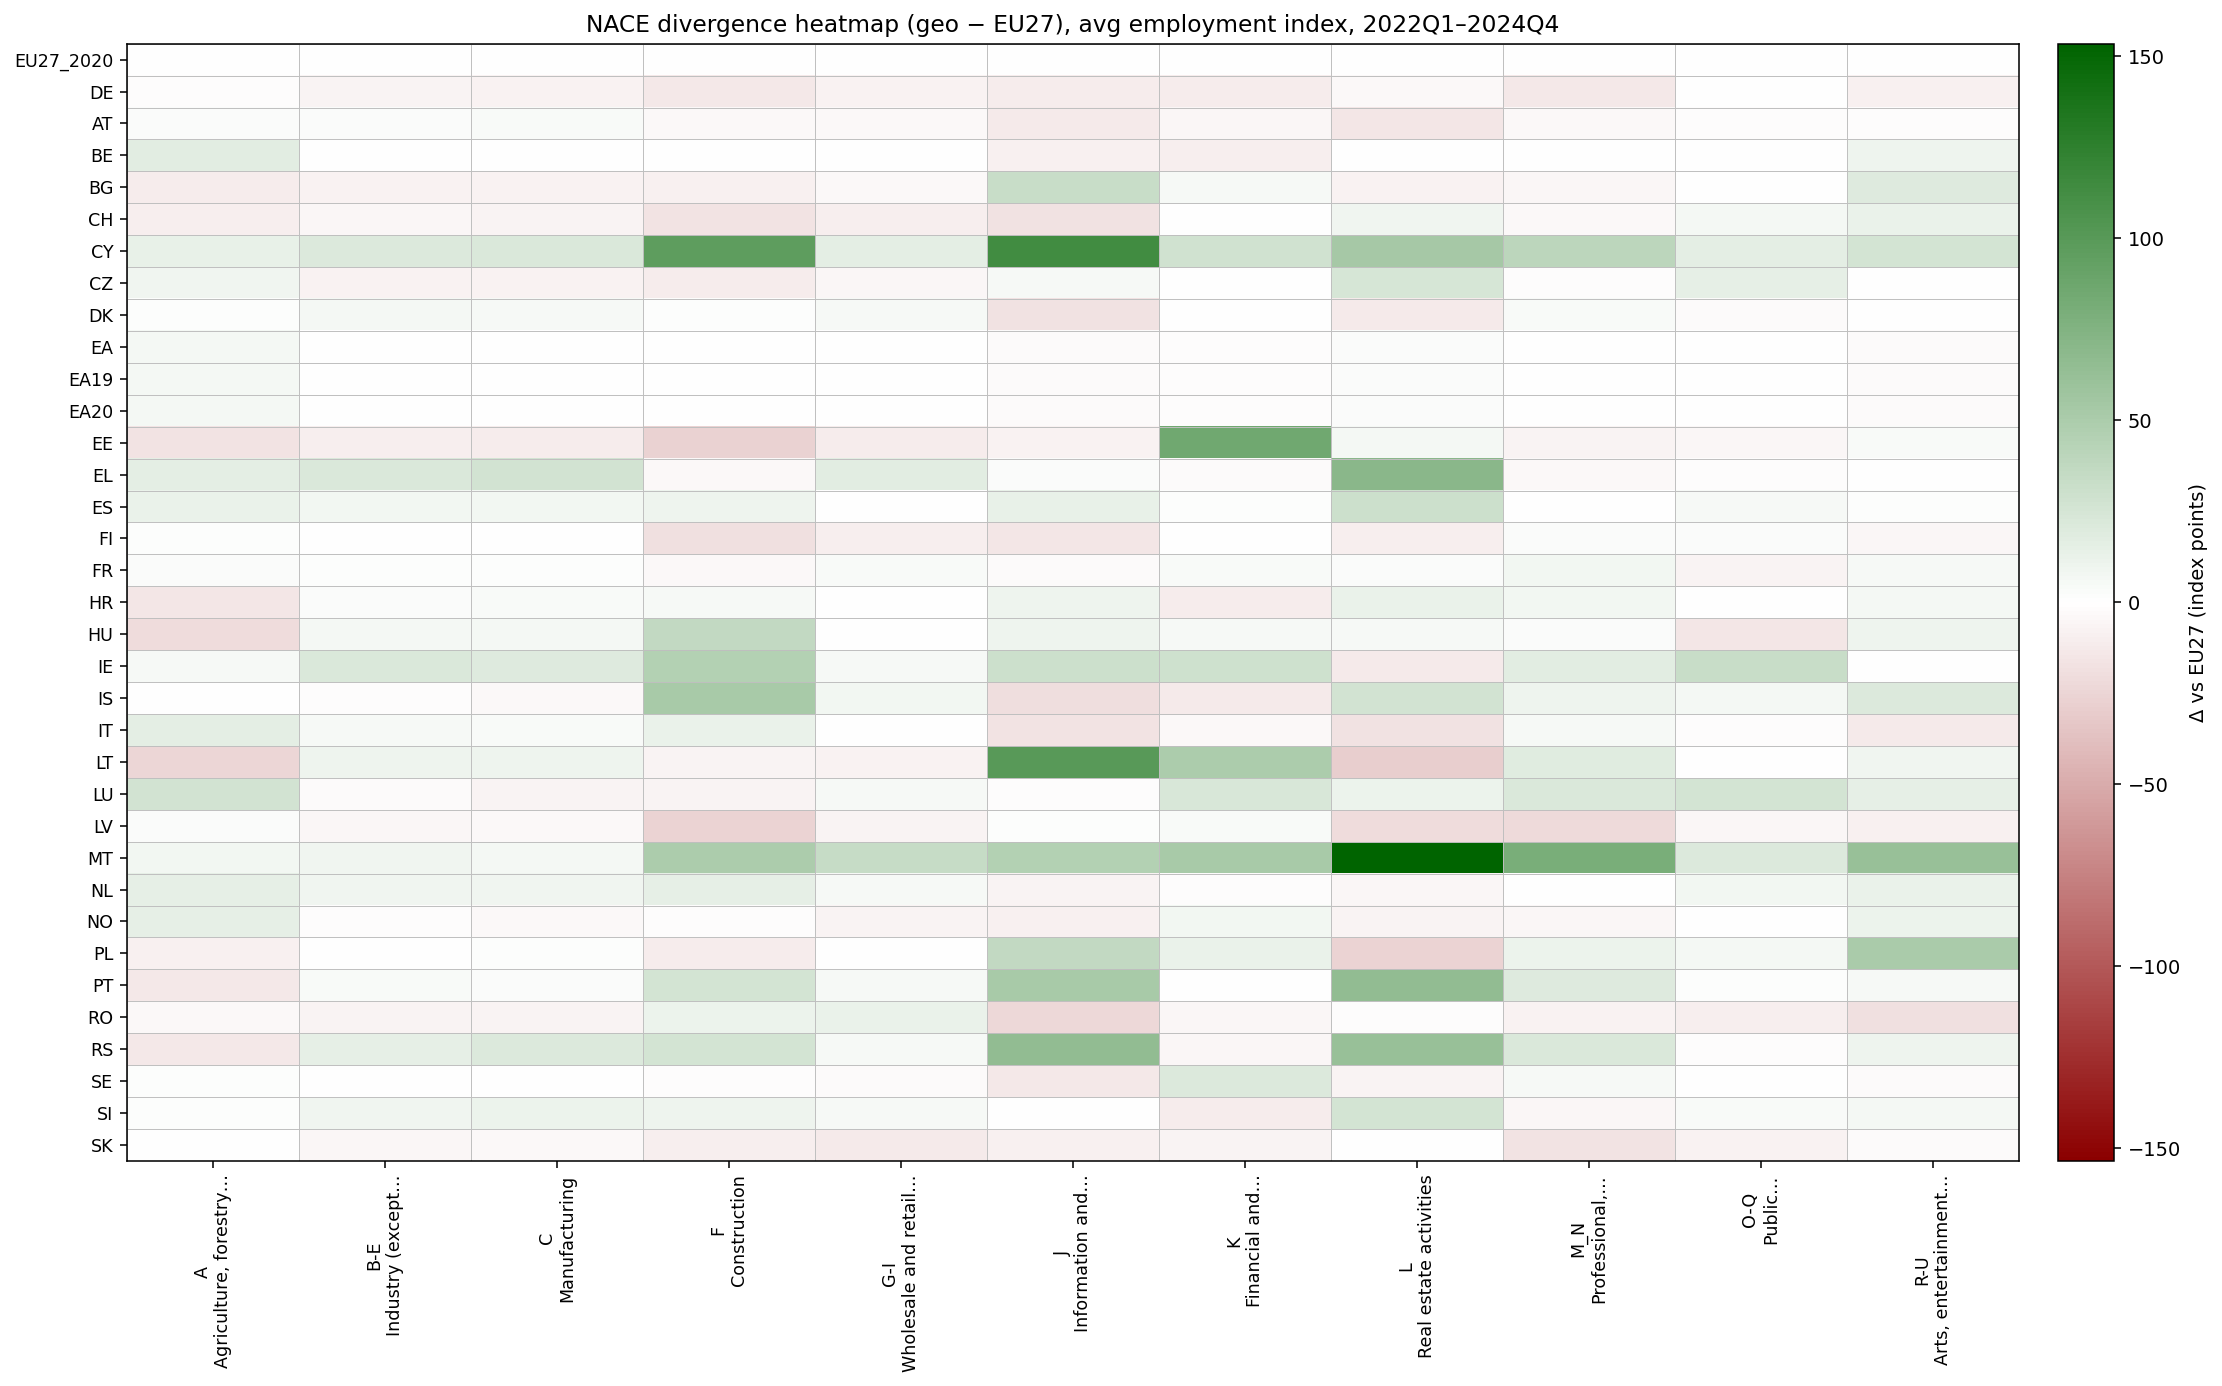

In [28]:
maskWindow = (dfNaceWideFiltered["timeQuarter"] >= windowStart) & (dfNaceWideFiltered["timeQuarter"] <= windowEnd)
dfWin = dfNaceWideFiltered.loc[maskWindow].copy()

sectorLevelCols = sorted([
    c for c in dfWin.columns
    if c.startswith("employmentIndex_") and (not c.endswith("_vs_eu27"))
])
sectorLevelCols = [c for c in sectorLevelCols if c != "employmentIndex_TOTAL"]

geoMeans = dfWin.groupby("geo")[sectorLevelCols].mean(numeric_only=True)
eu27Mean = geoMeans.loc["EU27_2020"]
delta = geoMeans.sub(eu27Mean, axis=1)  # includes EU27 row = 0

# order rows like your heatmap: EU27 first, DE second, then others alpha
geos = delta.index.tolist()
rest = sorted([g for g in geos if g not in ["EU27_2020", "DE"]])
rowOrder = ["EU27_2020", "DE"] + rest
delta = delta.loc[rowOrder]

# COICOP-like x tick labels: CODE on first line + shortened label below
origSectors = sorted(dfNace["nace_r2"].unique().tolist())
safeToOrig  = {s.replace("-", "_"): s for s in origSectors}
labelCol = "label" if "label" in dfNaceLabels.columns else dfNaceLabels.columns[-1]
labelMap = dict(zip(dfNaceLabels["nace_r2"].astype(str), dfNaceLabels[labelCol].astype(str)))

def shortLabel(code: str, lab: str, width: int = 22) -> str:
    return f"{code}\n{textwrap.shorten(str(lab), width=width, placeholder='…')}"

xLabels = []
for c in sectorLevelCols:
    safe = c.replace("employmentIndex_", "")
    code = safeToOrig.get(safe, safe)
    lab  = labelMap.get(code, code)
    xLabels.append(shortLabel(code, lab, width=22))

vals = delta.to_numpy(dtype=float)  # FIX for "dtype object cannot be converted to float"
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm

# --- symmetric normalization around 0 (keep as you have it) ---
maxAbs = float(np.nanmax(np.abs(vals)))
# maxAbs = float(np.nanpercentile(np.abs(vals), 98))  # optional: less washed-out if one outlier dominates
norm = TwoSlopeNorm(vmin=-maxAbs, vcenter=0.0, vmax=maxAbs)

# --- deep red (negative) -> white -> deep green (positive) ---
cmap_red_white_green = LinearSegmentedColormap.from_list(
    "red_white_green",
    ["#8B0000", "#FFFFFF", "#006400"],  # darkred, white, darkgreen
    N=256
)

fig, ax = plt.subplots(figsize=(16, 10), dpi=140)
im = ax.imshow(vals, aspect="auto", cmap=cmap_red_white_green, norm=norm)

ax.set_xticks(np.arange(len(sectorLevelCols)))
ax.set_xticklabels(xLabels, rotation=90, ha="center", fontsize=9)

ax.set_yticks(np.arange(len(delta.index)))
ax.set_yticklabels(delta.index.tolist(), fontsize=9)

# grid like your COICOP heatmap
ax.set_xticks(np.arange(-0.5, len(sectorLevelCols), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(delta.index), 1), minor=True)
ax.grid(which="minor", color="0.75", linestyle="-", linewidth=0.5)
ax.tick_params(which="minor", bottom=False, left=False)

# --- remove any previously-added highlight lines (EU/DE) ---
for ln in list(ax.lines):
    ln.remove()

ax.set_title(f"NACE divergence heatmap (geo − EU27), avg employment index, {windowStart}–{windowEnd}")

cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label("Δ vs EU27 (index points)")

fig.tight_layout()
plt.show()


In [29]:
stem = f"nace_divergence_heatmap_allGeos_{windowStart}_{windowEnd}"
figPath = figuresDir / f"{stem}.png"

fig.savefig(figPath, dpi=200, bbox_inches="tight")
print("Saved figure:", figPath)


Saved figure: /Users/princebhanusteta/Documents/Projects/euro-macro-inflation-income/reports/figures/eda_nace/nace_divergence_heatmap_allGeos_2022Q1_2024Q4.png


### Feature Engineering

In [30]:
# --- Resolve project root robustly (so we never save into /notebooks by accident)
CWD = Path.cwd()
PROJECT_ROOT = CWD.parent if CWD.name == "notebooks" else CWD

DATA_PROCESSED = PROJECT_ROOT / "data_processed"
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)

# --- Load long NACE sector panel
nace_path = DATA_PROCESSED / "employment_sector_panel_nace.parquet"
df_nace = pd.read_parquet(nace_path)

# Basic schema expectations (fail loudly if something is off)
required_cols = {"geo", "timeQuarter", "nace_r2", "employmentIndex"}
missing = required_cols - set(df_nace.columns)
if missing:
    raise ValueError(f"Missing expected columns in NACE panel: {missing}")

# Ensure Period dtype for timeQuarter if needed
if not pd.api.types.is_period_dtype(df_nace["timeQuarter"]):
    df_nace["timeQuarter"] = df_nace["timeQuarter"].astype("period[Q-DEC]")

# --- Filter to ML window (align with macro/coicop FE convention)
start_q = pd.Period("2010Q1", freq="Q-DEC")
end_q   = pd.Period("2024Q4", freq="Q-DEC")
df_nace = df_nace[(df_nace["timeQuarter"] >= start_q) & (df_nace["timeQuarter"] <= end_q)].copy()

# Key uniqueness check
key_cols = ["geo", "timeQuarter", "nace_r2"]
dup = df_nace.duplicated(key_cols).sum()
if dup:
    raise ValueError(f"Duplicate (geo,timeQuarter,nace_r2) rows found: {dup}")

# --- Pivot to geo×quarter wide (safe column names: B-E -> B_E)
sector_code_map = {s: s.replace("-", "_") for s in sorted(df_nace["nace_r2"].unique())}
df_wide = (
    df_nace.assign(naceCodeSafe=df_nace["nace_r2"].map(sector_code_map))
           .pivot(index=["geo", "timeQuarter"], columns="naceCodeSafe", values="employmentIndex")
           .sort_index()
)
df_wide.columns = [f"employmentIndex_{c}" for c in df_wide.columns]
df_wide = df_wide.reset_index()

# --- Add EU27 benchmark levels per quarter + divergences vs EU27 (country - EU27)
EU27_CODE = "EU27_2020"
eu27 = (
    df_wide[df_wide["geo"] == EU27_CODE]
    .drop(columns=["geo"])
    .rename(columns={c: f"eu27_{c}" for c in df_wide.columns if c.startswith("employmentIndex_")})
)
df_wide = df_wide.merge(eu27, on="timeQuarter", how="left", validate="m:1")

sector_level_cols = [c for c in df_wide.columns if c.startswith("employmentIndex_")]
for c in sector_level_cols:
    df_wide[f"{c}_vs_eu27"] = df_wide[c] - df_wide[f"eu27_{c}"]

# --- Leakage-safe time features within each geo
df_wide = df_wide.sort_values(["geo", "timeQuarter"]).reset_index(drop=True)

def add_time_features(df: pd.DataFrame, cols: list[str], group_key: str = "geo") -> pd.DataFrame:
    g = df.groupby(group_key, sort=False)

    for c in cols:
        df[f"{c}_lag1"] = g[c].shift(1)
        df[f"{c}_lag4"] = g[c].shift(4)

        df[f"{c}_chg_qoq"] = df[c] - df[f"{c}_lag1"]
        df[f"{c}_chg_yoy"] = df[c] - df[f"{c}_lag4"]

        # trailing rolling window (t-3..t), no centering
        df[f"{c}_roll4_mean"] = g[c].rolling(4, min_periods=4).mean().reset_index(level=0, drop=True)
        df[f"{c}_roll4_std"]  = g[c].rolling(4, min_periods=4).std().reset_index(level=0, drop=True)

    return df

# Choose base columns for time features:
# - levels
# - divergences vs EU27
div_cols = [f"{c}_vs_eu27" for c in sector_level_cols]
base_for_time = sector_level_cols + div_cols

df_feat = add_time_features(df_wide.copy(), base_for_time, group_key="geo")

# --- Episode flags (simple, interpretable)
t = df_feat["timeQuarter"]
df_feat["is_eurodebt"]    = (t >= pd.Period("2010Q1", "Q-DEC")) & (t <= pd.Period("2013Q4", "Q-DEC"))
df_feat["is_covid"]       = (t >= pd.Period("2020Q1", "Q-DEC")) & (t <= pd.Period("2021Q4", "Q-DEC"))
df_feat["is_infl_surge"]  = (t >= pd.Period("2021Q2", "Q-DEC")) & (t <= pd.Period("2022Q4", "Q-DEC"))
df_feat["is_post_surge"]  = (t >= pd.Period("2023Q1", "Q-DEC")) & (t <= pd.Period("2024Q4", "Q-DEC"))

# --- Final save
OUT_PARQUET = DATA_PROCESSED / "ml_nace_features_2010_2024.parquet"

# Feature columns = everything except keys
KEYS = ["geo", "timeQuarter"]
feature_cols = [c for c in df_feat.columns if c not in KEYS]

df_feat.to_parquet(OUT_PARQUET, index=False)
print("Saved:", OUT_PARQUET)
print("Shape:", df_feat.shape)



Saved: /Users/princebhanusteta/Documents/Projects/euro-macro-inflation-income/data_processed/ml_nace_features_2010_2024.parquet
Shape: (2160, 186)


/var/folders/24/3d0f7zg559dcdt3smmt22yr40000gn/T/ipykernel_9477/2932492740.py:19: DeprecationWarning: is_period_dtype is deprecated and will be removed in a future version. Use `isinstance(dtype, pd.PeriodDtype)` instead
  if not pd.api.types.is_period_dtype(df_nace["timeQuarter"]):


In [31]:
# Basic missingness + range sanity
chk = df_feat.copy()

print("Geos:", chk["geo"].nunique(), " Quarters:", chk["timeQuarter"].nunique())
print("EU27 present:", (chk["geo"] == "EU27_2020").any())

# How many NaNs are created by lag/rolling mechanics (expected at the start of each geo series)
nan_rate = chk.drop(columns=["geo", "timeQuarter"]).isna().mean().sort_values(ascending=False).head(15)
display(nan_rate.to_frame("nan_rate_top15"))

# Confirm EU27 divergences ~0 for EU27 row (should be 0 or very close, except where missing)
eu27_rows = chk[chk["geo"] == "EU27_2020"]
div_cols = [c for c in chk.columns if c.endswith("_vs_eu27")]
print("EU27 divergence abs max (ignoring NaN):", np.nanmax(np.abs(eu27_rows[div_cols].to_numpy(dtype=float))))


Geos: 36  Quarters: 60
EU27 present: True


,nan_rate_top15
employmentIndex_C_chg_yoy,0.074537
employmentIndex_A_chg_yoy,0.074537
employmentIndex_G_I_vs_eu27_chg_yoy,0.074537
employmentIndex_M_N_chg_yoy,0.074537
employmentIndex_L_vs_eu27_chg_yoy,0.074537
employmentIndex_K_vs_eu27_chg_yoy,0.074537
employmentIndex_F_vs_eu27_chg_yoy,0.074537
employmentIndex_L_chg_yoy,0.074537
employmentIndex_A_vs_eu27_chg_yoy,0.074537
employmentIndex_O_Q_chg_yoy,0.074537


EU27 divergence abs max (ignoring NaN): 0.0


In [32]:
# assuming your final engineered wide table is df_feat with columns:
# ["geo","timeQuarter", employmentIndex_* ... and employmentIndex_*_vs_eu27 ...]
vs_cols = [c for c in df_feat.columns if c.endswith("_vs_eu27")]

# EU27 should be ~0 everywhere (numerical noise aside)
eu27_abs_max = df_feat.loc[df_feat["geo"].eq("EU27_2020"), vs_cols].abs().max().max()

# NON-EU geos should show non-zero divergences
non_eu_abs_max = df_feat.loc[~df_feat["geo"].eq("EU27_2020"), vs_cols].abs().max().max()

print("EU27 row abs max (should be 0):", eu27_abs_max)
print("Non-EU abs max (should be >0):", non_eu_abs_max)

# quick peek: biggest divergences
top = (
    df_feat.loc[~df_feat["geo"].eq("EU27_2020"), ["geo","timeQuarter"] + vs_cols]
      .set_index(["geo","timeQuarter"])
      .abs()
      .max()
      .sort_values(ascending=False)
      .head(10)
)
display(top)


EU27 row abs max (should be 0): 0.0
Non-EU abs max (should be >0): 208.09999999999997


employmentIndex_L_vs_eu27        208.1
employmentIndex_J_vs_eu27        136.3
employmentIndex_K_vs_eu27        123.1
employmentIndex_F_vs_eu27         99.3
employmentIndex_M_N_vs_eu27       97.7
employmentIndex_A_vs_eu27         75.1
employmentIndex_R_U_vs_eu27       69.2
employmentIndex_TOTAL_vs_eu27     49.6
employmentIndex_G_I_vs_eu27       47.9
employmentIndex_O_Q_vs_eu27       38.4
dtype: Float64

In [33]:
vs_cols = [c for c in df_feat.columns if c.endswith("_vs_eu27")]

# Which feature has the biggest absolute value?
abs_max_by_col = df_feat.loc[~df_feat["geo"].eq("EU27_2020"), vs_cols].abs().max()
top_col = abs_max_by_col.idxmax()
top_val = abs_max_by_col.max()

print("Top divergence column:", top_col)
print("Top divergence abs value:", top_val)

# Show the geo-quarter rows where that maximum happens
mask = df_feat[top_col].abs().eq(top_val)
display(df_feat.loc[mask, ["geo", "timeQuarter", top_col]].sort_values(["geo","timeQuarter"]))


Top divergence column: employmentIndex_L_vs_eu27
Top divergence abs value: 208.09999999999997


,geo,timeQuarter,employmentIndex_L_vs_eu27
1556,MT,2024Q1,208.1


In [34]:
KEY_COLS = ["geo", "timeQuarter"]

# 1) Choose columns to clip (centered around 0)
CLIP_Q = 0.99  # 99th percentile of absolute values

div_cols = [c for c in df_feat.columns if ("_vs_eu27" in c) and (c not in KEY_COLS)]
chg_cols = [c for c in df_feat.columns if (c.endswith("_chg_qoq") or c.endswith("_chg_yoy")) and (c not in KEY_COLS)]

clip_cols = [c for c in sorted(set(div_cols + chg_cols)) if pd.api.types.is_numeric_dtype(df_feat[c])]

# 2) Compute symmetric per-column bounds and clip
abs_bounds = df_feat[clip_cols].abs().quantile(CLIP_Q)          # Series indexed by column
abs_bounds = abs_bounds.replace(0, np.nan).fillna(0.0)         # safety

before = df_feat[clip_cols].copy()
df_feat.loc[:, clip_cols] = df_feat[clip_cols].clip(lower=-abs_bounds, upper=abs_bounds, axis=1)

# 3) Quick audit: how much got clipped?
clipped_counts = (df_feat[clip_cols].ne(before)).sum().sort_values(ascending=False)
print("Top clipped columns (count of changed cells):")
print(clipped_counts.head(15))




Top clipped columns (count of changed cells):
employmentIndex_TOTAL_vs_eu27_roll4_std    146
employmentIndex_O_Q_vs_eu27_roll4_mean     146
employmentIndex_L_vs_eu27_roll4_std        146
employmentIndex_C_vs_eu27_roll4_std        146
employmentIndex_C_vs_eu27_roll4_mean       146
employmentIndex_F_vs_eu27_roll4_mean       146
employmentIndex_F_vs_eu27_roll4_std        146
employmentIndex_M_N_vs_eu27_roll4_mean     146
employmentIndex_M_N_vs_eu27_roll4_std      146
employmentIndex_K_vs_eu27_roll4_std        146
employmentIndex_K_vs_eu27_roll4_mean       146
employmentIndex_B_E_vs_eu27_roll4_std      146
employmentIndex_B_E_vs_eu27_roll4_mean     146
employmentIndex_L_vs_eu27_roll4_mean       146
employmentIndex_O_Q_vs_eu27_roll4_std      146
dtype: Int64


In [35]:
# --- expected project paths (root-relative) ---
CWD = Path.cwd()
PROJECT_ROOT = CWD.parent if CWD.name == "notebooks" else CWD
DATA_PROCESSED = PROJECT_ROOT / "data_processed"
REPORTS_DIR = PROJECT_ROOT / "reports"
TABLES_DIR = REPORTS_DIR / "tables" 

DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

KEY_COLS = ["geo", "timeQuarter"]

# Optional: drop TOTAL everywhere
drop_total = [c for c in df_feat.columns if "TOTAL" in c]
dfSave = df_feat.drop(columns=drop_total, errors="ignore").copy()

# Save feature table
out_parquet = DATA_PROCESSED / "ml_nace_features_2010_2024.parquet"
dfSave.to_parquet(out_parquet, index=False)
print("Saved:", out_parquet)

# Deterministic X column list (no targets here)
X_COLS = [c for c in dfSave.columns if c not in KEY_COLS]
xcols_path = TABLES_DIR / "ml_nace_X_cols_2010_2024.txt"
xcols_path.write_text("\n".join(X_COLS))
print("Saved:", xcols_path)

# Feature manifest for auditability
def feature_family(col: str) -> str:
    if col in KEY_COLS: return "key"
    if col.endswith("_vs_eu27"): return "divergence_level"
    if "_vs_eu27_" in col: return "divergence_engineered"
    if "_lag" in col: return "lag"
    if "_chg_qoq" in col: return "chg_qoq"
    if "_chg_yoy" in col: return "chg_yoy"
    if "_roll4_" in col: return "roll4"
    if col.startswith("employmentIndex_"): return "level"
    return "other"

manifest = (
    dfSave.columns.to_series()
    .to_frame("feature")
    .assign(family=lambda d: d["feature"].map(feature_family))
)

manifest_path = TABLES_DIR / "ml_nace_feature_manifest_2010_2024.csv"
manifest.to_csv(manifest_path, index=False)
print("Saved:", manifest_path)


Saved: /Users/princebhanusteta/Documents/Projects/euro-macro-inflation-income/data_processed/ml_nace_features_2010_2024.parquet
Saved: /Users/princebhanusteta/Documents/Projects/euro-macro-inflation-income/reports/tables/ml_nace_X_cols_2010_2024.txt
Saved: /Users/princebhanusteta/Documents/Projects/euro-macro-inflation-income/reports/tables/ml_nace_feature_manifest_2010_2024.csv
